<sub>`Data Science | Market Intelligence`</sub>

# **TALENT MARKET SKILL DRIFT STUDY**

---

#### **Analisis Temporal Permintaan Skill, Ekosistem Co-occurrence, dan Profil Kompetensi per Role pada Pasar Data Jobs Amerika Serikat (2023): Pendekatan Temporal Frequency Analysis, PMI Network, dan TF-IDF Adapted Distinctiveness**

## **`[1]` Import Library**

In [ ]:
# ==================================================
# 1. IMPORT LIBRARY
# ==================================================

import warnings
warnings.filterwarnings('ignore')

import ast
import math
import itertools
from collections import Counter

import numpy as np
import pandas as pd
from datasets import load_dataset
from scipy.stats import chi2_contingency

import networkx as nx
from networkx.algorithms.community import greedy_modularity_communities

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display

# Library opsional dengan graceful fallback
try:
    import pymannkendall as mk
    MANNKENDALL_AVAILABLE = True
except ImportError:
    MANNKENDALL_AVAILABLE = False

try:
    import community as community_louvain
    LOUVAIN_AVAILABLE = True
except ImportError:
    LOUVAIN_AVAILABLE = False

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 80)
pd.set_option('display.float_format', '{:.4f}'.format)

print("Import selesai.")
print(f"  numpy          : {np.__version__}")
print(f"  pandas         : {pd.__version__}")
print(f"  pymannkendall  : {'tersedia' if MANNKENDALL_AVAILABLE else 'tidak tersedia'}")
print(f"  python-louvain : {'tersedia' if LOUVAIN_AVAILABLE else 'tidak tersedia (fallback: greedy modularity)'}")

Import selesai.
  numpy          : 1.26.4
  pandas         : 2.2.2
  pymannkendall  : tidak tersedia
  python-louvain : tidak tersedia (fallback: greedy modularity)


## **`[2]` Konfigurasi Reproducibility**

In [ ]:
# ==================================================
# 2. KONFIGURASI REPRODUCIBILITY
# ==================================================

#---------------------------------------------------
# 2.1 Random State
#---------------------------------------------------
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

#---------------------------------------------------
# 2.2 Parameter Analisis
#---------------------------------------------------
MIN_SKILL_FREQ     = 500   # Minimum total frekuensi skill untuk growth analysis
TOP_N_SKILLS_EDA   = 30    # Top N skills untuk EDA overview
TOP_N_SKILLS_NET   = 75    # Top N skills untuk co-occurrence network
TOP_N_SKILLS_TREND = 10    # Top N skills untuk line chart temporal
TOP_N_SKILLS_MAT   = 40    # Top N skills untuk TF-IDF role matrix
MIN_ROLE_SIZE      = 1000  # Minimum posting per role untuk komparasi valid
MIN_MONTHLY_VOL    = 3000  # Minimum posting per bulan (gate validasi temporal)
PMI_THRESHOLD      = 0.3   # Minimum PMI untuk edge pada network
EDGE_WEIGHT_MIN    = 50    # Minimum co-occurrence count untuk edge

#---------------------------------------------------
# 2.3 Konfigurasi Visualisasi
#---------------------------------------------------
try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    plt.style.use('ggplot')

FIGSIZE_STD    = (13, 6)
FIGSIZE_WIDE   = (16, 8)
FIGSIZE_TALL   = (13, 10)
FIGSIZE_SQUARE = (11, 9)
DPI            = 110

COLOR_RISING    = '#1565C0'
COLOR_DECLINING = '#B71C1C'
COLOR_NEUTRAL   = '#616161'
COLOR_ACCENT    = '#E65100'

#---------------------------------------------------
# 2.4 Filter Tanggal
#---------------------------------------------------
DATE_START = '2023-01-01'
DATE_END   = '2023-12-31'

print("Konfigurasi selesai.")
print(f"  RANDOM_STATE       : {RANDOM_STATE}")
print(f"  MIN_SKILL_FREQ     : {MIN_SKILL_FREQ:,}")
print(f"  TOP_N_SKILLS_NET   : {TOP_N_SKILLS_NET}")
print(f"  TOP_N_SKILLS_TREND : {TOP_N_SKILLS_TREND}")
print(f"  MIN_MONTHLY_VOL    : {MIN_MONTHLY_VOL:,}")
print(f"  Filter tanggal     : {DATE_START} s/d {DATE_END}")

Konfigurasi selesai.
  RANDOM_STATE       : 42
  MIN_SKILL_FREQ     : 500
  TOP_N_SKILLS_NET   : 75
  TOP_N_SKILLS_TREND : 10
  MIN_MONTHLY_VOL    : 3,000
  Filter tanggal     : 2023-01-01 s/d 2023-12-31


## **`[3]` Data Acquisition dan Overview**

Dataset dimuat langsung dari Hugging Face. Sebelum preprocessing dimulai, dilakukan tiga pemeriksaan yaitu inventaris kolom, tipe data, dan distribusi temporal sebagai gate validasi yang menentukan kelayakan analisis trend.

In [ ]:
# ==================================================
# 3. DATA ACQUISITION DAN OVERVIEW
# ==================================================

#---------------------------------------------------
# 3.1 Load Dataset dari Hugging Face
#---------------------------------------------------
from datasets import load_dataset
ds = load_dataset("lukebarousse/data_jobs")

df_raw = ds['train'].to_pandas()

print("Dataset berhasil dimuat.")
print(f"  Shape  : {df_raw.shape[0]:,} baris x {df_raw.shape[1]} kolom")
print(f"  Kolom  : {list(df_raw.columns)}")

Dataset berhasil dimuat.
  Shape  : 785,741 baris x 17 kolom
  Kolom  : ['job_title_short', 'job_title', 'job_location', 'job_via', 'job_schedule_type', 'job_work_from_home', 'search_location', 'job_posted_date', 'job_no_degree_mention', 'job_health_insurance', 'job_country', 'salary_rate', 'salary_year_avg', 'salary_hour_avg', 'company_name', 'job_skills', 'job_type_skills']


In [ ]:
#---------------------------------------------------
# 3.2 Data Inventory
#---------------------------------------------------
dtype_summary = pd.DataFrame({
    'dtype'      : df_raw.dtypes,
    'null_count' : df_raw.isnull().sum(),
    'null_pct'   : (df_raw.isnull().sum() / len(df_raw) * 100).round(2),
    'unique_vals': df_raw.nunique()
})

print("=== INVENTARIS KOLOM ===")
display(dtype_summary)

print("\n=== SAMPLE DATA (3 BARIS) ===")
display(df_raw.head(3))

=== INVENTARIS KOLOM ===


,dtype,null_count,null_pct,unique_vals
job_title_short,object,0,0.0000,10
job_title,object,1,0.0000,234673
job_location,object,1045,0.1300,17217
job_via,object,8,0.0000,7903
job_schedule_type,object,12667,1.6100,47
job_work_from_home,bool,0,0.0000,2
search_location,object,0,0.0000,173
job_posted_date,object,0,0.0000,607192
job_no_degree_mention,bool,0,0.0000,2
job_health_insurance,bool,0,0.0000,2



=== SAMPLE DATA (3 BARIS) ===


,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clinical Data Engineer ...,"Watertown, CT",via Work Nearby,Full-time,False,"Texas, United States",2023-06-16 13:44:15,False,False,United States,None,NaN,NaN,Boehringer Ingelheim,None,None
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,None,NaN,NaN,Hewlett Packard Enterprise,"['r', 'python', 'sql', 'nosql', 'power bi', 'tableau']","{'analyst_tools': ['power bi', 'tableau'], 'programming': ['r', 'python', 's..."
2,Data Engineer,"Data Engineer/Scientist/Analyst, Mid or Senior (m/f/x)","Berlin, Germany",via LinkedIn,Full-time,False,Germany,2023-10-10 13:14:55,False,False,Germany,None,NaN,NaN,ALPHA Augmented Services,"['python', 'sql', 'c#', 'azure', 'airflow', 'dax', 'docker', 'kubernetes', '...","{'analyst_tools': ['dax'], 'cloud': ['azure'], 'libraries': ['airflow'], 'ot..."


In [ ]:
import os

os.makedirs("../outputs/figures", exist_ok=True)

_original_savefig = plt.savefig

def savefig_hook(fname, *args, **kwargs):
    filename = os.path.basename(str(fname))
    new_path = os.path.join("../outputs/figures", filename)

    print(f"Saving -> {new_path}")

    return _original_savefig(new_path, *args, **kwargs)

plt.savefig = savefig_hook

Saving -> ../outputs/figures\plot_temporal_coverage.png


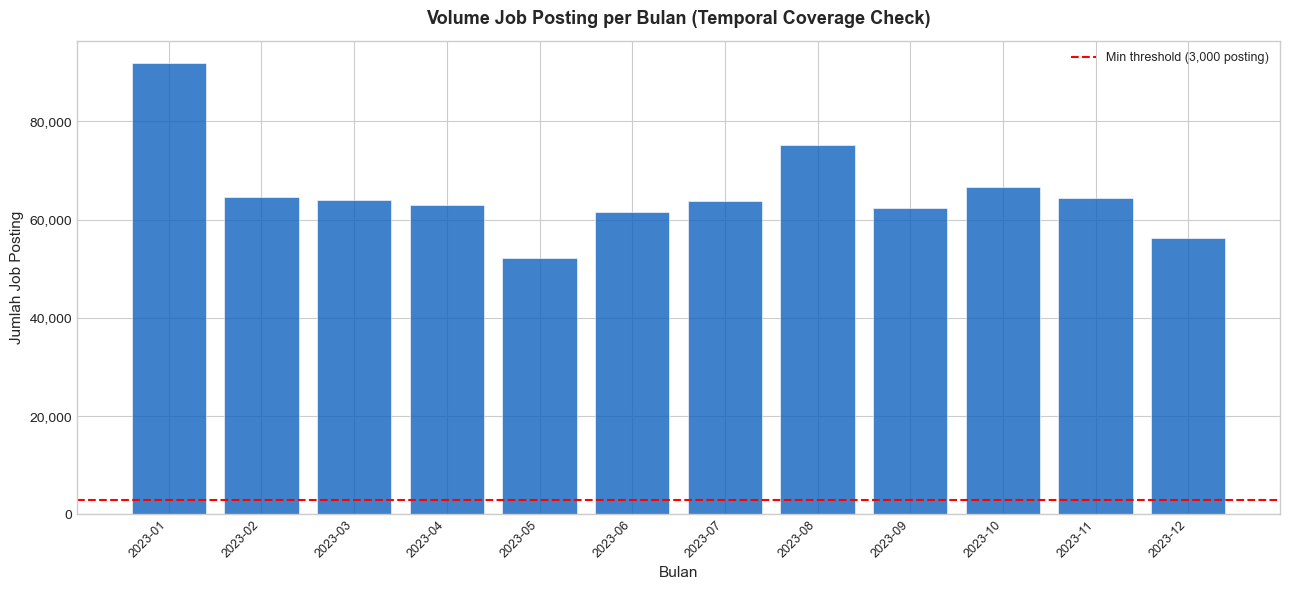

Range tanggal          : 2023-01-01 00:00:04 s/d 2023-12-31 23:59:58
Total bulan            : 12
Bulan valid (>= 3,000): 12

Distribusi per bulan:
year_month_check
2023-01    91822
2023-02    64578
2023-03    64084
2023-04    62919
2023-05    52104
2023-06    61572
2023-07    63777
2023-08    75162
2023-09    62359
2023-10    66611
2023-11    64450
2023-12    56303
Freq: M


In [ ]:
#---------------------------------------------------
# 3.3 Temporal Coverage Validation
#---------------------------------------------------
df_temp = df_raw[['job_posted_date']].copy()
df_temp['date_parsed']       = pd.to_datetime(df_temp['job_posted_date'], errors='coerce')
df_temp['year_month_check']  = df_temp['date_parsed'].dt.to_period('M')

monthly_check = df_temp['year_month_check'].value_counts().sort_index()

_original_subplots = plt.subplots
saved_figures = []

def subplots_hook(*args, **kwargs):
    fig, ax = _original_subplots(*args, **kwargs)
    saved_figures.append(fig)
    return fig, ax

plt.subplots = subplots_hook

fig, ax = plt.subplots(figsize=FIGSIZE_STD)
x_pos = list(range(len(monthly_check)))
ax.bar(x_pos, monthly_check.values, color=COLOR_RISING, alpha=0.82, edgecolor='white', linewidth=0.5)
ax.axhline(MIN_MONTHLY_VOL, color='red', linestyle='--', linewidth=1.5,
           label=f'Min threshold ({MIN_MONTHLY_VOL:,} posting)')
ax.set_xticks(x_pos)
ax.set_xticklabels([str(p) for p in monthly_check.index], rotation=45, ha='right', fontsize=9)
ax.set_title('Volume Job Posting per Bulan (Temporal Coverage Check)',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Bulan', fontsize=11)
ax.set_ylabel('Jumlah Job Posting', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{int(x):,}'))
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('plot_temporal_coverage.png', dpi=DPI, bbox_inches='tight')
plt.show()

date_min   = df_temp['date_parsed'].min()
date_max   = df_temp['date_parsed'].max()
n_valid    = (monthly_check >= MIN_MONTHLY_VOL).sum()
print(f"Range tanggal          : {date_min} s/d {date_max}")
print(f"Total bulan            : {len(monthly_check)}")
print(f"Bulan valid (>= {MIN_MONTHLY_VOL:,}): {n_valid}")
print("\nDistribusi per bulan:")
print(monthly_check.to_string())

## **`[4]` Data Quality Assessment**

Tiga pemeriksaan kualitas yang dilakukan sebelum preprocessing yaitu profil missing value per kolom, potensi duplikasi lintas platform, dan kelayakan parsing kolom `job_skills`.

Saving -> ../outputs/figures\plot_missing_values.png


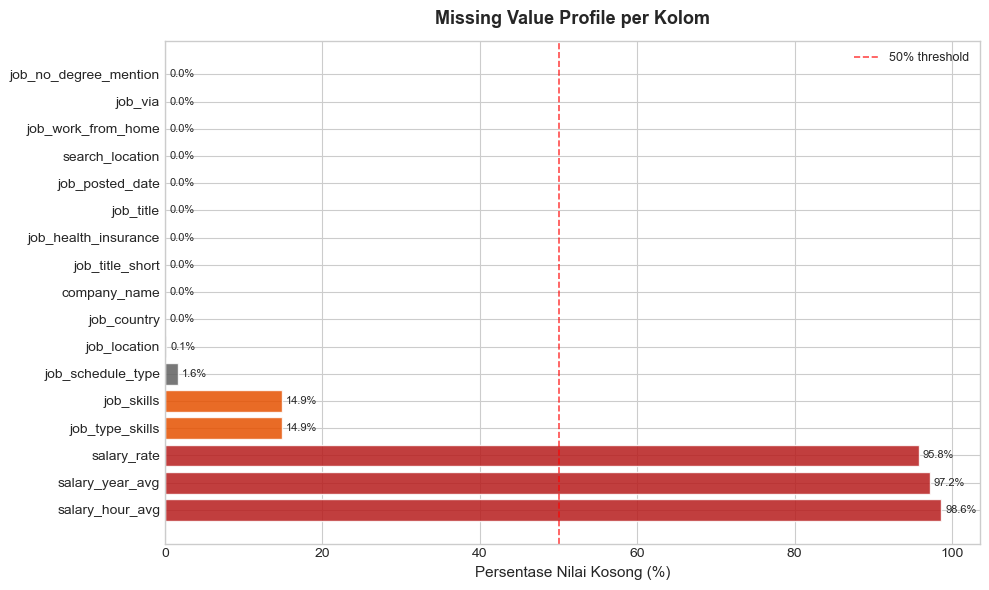

,null_count,null_pct
salary_hour_avg,775079,98.6400
salary_year_avg,763738,97.2000
salary_rate,752674,95.7900
job_type_skills,117037,14.9000
job_skills,117037,14.9000
job_schedule_type,12667,1.6100
job_location,1045,0.1300
job_country,49,0.0100
company_name,18,0.0000
job_title,1,0.0000


In [ ]:
# ==================================================
# 4. DATA QUALITY ASSESSMENT
# ==================================================

#---------------------------------------------------
# 4.1 Missing Value Profile
#---------------------------------------------------
null_profile = pd.DataFrame({
    'null_count': df_raw.isnull().sum(),
    'null_pct'  : (df_raw.isnull().sum() / len(df_raw) * 100).round(2)
}).sort_values('null_pct', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
bar_colors = [COLOR_DECLINING if p > 50 else COLOR_ACCENT if p > 10 else COLOR_NEUTRAL
              for p in null_profile['null_pct']]
bars = ax.barh(null_profile.index, null_profile['null_pct'],
               color=bar_colors, alpha=0.85, edgecolor='white')
ax.axvline(50, color='red', linestyle='--', linewidth=1.2, alpha=0.7, label='50% threshold')
ax.set_xlabel('Persentase Nilai Kosong (%)', fontsize=11)
ax.set_title('Missing Value Profile per Kolom', fontsize=13, fontweight='bold', pad=12)
ax.legend(fontsize=9)

for bar, val in zip(bars, null_profile['null_pct']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('plot_missing_values.png', dpi=DPI, bbox_inches='tight')
plt.show()

display(null_profile[null_profile['null_count'] > 0])

Profil missing value mengungkap pola yang khas pada dataset job posting. Kolom `salary_year_avg` dan `salary_hour_avg` umumnya memiliki missing value sangat tinggi karena banyak perusahaan tidak mencantumkan range gaji secara publik. Ini membatasi analisis salary-skill menjadi supplementary saja, dengan catatan bahwa sampel yang tersedia tidak mewakili seluruh pasar.

In [ ]:
#---------------------------------------------------
# 4.2 Duplicate Assessment
#---------------------------------------------------
dedup_cols = ['job_title', 'company_name', 'job_location', 'job_posted_date']
n_total    = len(df_raw)
n_dupes    = df_raw.duplicated(subset=dedup_cols, keep=False).sum()
n_unique   = df_raw.drop_duplicates(subset=dedup_cols, keep='first').shape[0]

print("=== DUPLIKASI ASSESSMENT ===")
print(f"Total baris           : {n_total:,}")
print(f"Baris duplikat        : {n_dupes:,} ({n_dupes / n_total * 100:.2f}%)")
print(f"Baris unik (estimasi) : {n_unique:,}")
print(f"\nStrategi  : deduplicate dengan keep='first'")
print(f"Asumsi    : kombinasi job_title + company_name + job_location + posted_date")
print(f"            merepresentasikan satu posting unik di satu titik waktu.")

=== DUPLIKASI ASSESSMENT ===
Total baris           : 785,741
Baris duplikat        : 1,611 (0.21%)
Baris unik (estimasi) : 784,897

Strategi  : deduplicate dengan keep='first'
Asumsi    : kombinasi job_title + company_name + job_location + posted_date
            merepresentasikan satu posting unik di satu titik waktu.


In [ ]:
#---------------------------------------------------
# 4.3 Skill Parsing Quality Check (Sample Test)
#---------------------------------------------------
sample_size    = 1000
sample_skills  = df_raw['job_skills'].head(sample_size)

parse_success = parse_empty = parse_error = 0
for x in sample_skills:
    if pd.isna(x) or x is None:
        parse_empty += 1
    elif isinstance(x, list):
        parse_success += 1
    else:
        try:
            result = ast.literal_eval(str(x))
            if isinstance(result, list) and len(result) > 0:
                parse_success += 1
            else:
                parse_empty += 1
        except (ValueError, SyntaxError):
            parse_error += 1

print(f"=== SKILL PARSING TEST ({sample_size} baris sample) ===")
print(f"  Berhasil parse  : {parse_success} ({parse_success / sample_size * 100:.1f}%)")
print(f"  Parse kosong    : {parse_empty}  ({parse_empty / sample_size * 100:.1f}%)")
print(f"  Parse error     : {parse_error}  ({parse_error / sample_size * 100:.1f}%)")

# Tampilkan contoh hasil
valid_idx = df_raw['job_skills'].dropna().head(5).index
print("\nContoh nilai job_skills (mentah):")
for i in valid_idx[:3]:
    raw = df_raw.loc[i, 'job_skills']
    print(f"  [{i}] {str(raw)[:80]}...")

=== SKILL PARSING TEST (1000 baris sample) ===
  Berhasil parse  : 894 (89.4%)
  Parse kosong    : 106  (10.6%)
  Parse error     : 0  (0.0%)

Contoh nilai job_skills (mentah):
  [1] ['r', 'python', 'sql', 'nosql', 'power bi', 'tableau']...
  [2] ['python', 'sql', 'c#', 'azure', 'airflow', 'dax', 'docker', 'kubernetes', 'jenk...
  [3] ['python', 'c++', 'java', 'matlab', 'aws', 'tensorflow', 'keras', 'pytorch']...


Hasil parsing test menentukan apakah preprocessing dapat dilanjutkan atau tidak. Parse success rate di atas 80% dari sample dianggap cukup untuk analisis. Parse error yang terjadi ditangani dengan fallback function yang mengembalikan list kosong `[]`, artinya posting tersebut dikeluarkan dari analisis skill tanpa menghentikan proses keseluruhan.

## **`[5]` Preprocessing Pipeline**

Pipeline preprocessing menghasilkan tiga artefak utama yang menjadi fondasi seluruh analisis: `df` (DataFrame bersih), `df_skills_long` (long-format satu baris per skill), dan `valid_months` (daftar bulan yang valid).

In [ ]:
# ==================================================
# 5. PREPROCESSING PIPELINE
# ==================================================

#---------------------------------------------------
# 5.1 Parsing Datetime dan Filter Temporal
#---------------------------------------------------
df = df_raw.copy()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'], errors='coerce')
df['year_month']      = df['job_posted_date'].dt.to_period('M')
df['quarter']         = df['job_posted_date'].dt.to_period('Q')
df['month']           = df['job_posted_date'].dt.month
df['year']            = df['job_posted_date'].dt.year

mask_date = (
    (df['job_posted_date'] >= DATE_START) &
    (df['job_posted_date'] <= DATE_END) &
    df['job_posted_date'].notna()
)
df = df[mask_date].copy()

print(f"Setelah filter tanggal ({DATE_START} s/d {DATE_END}):")
print(f"  Baris tersisa: {len(df):,}")

#---------------------------------------------------
# 5.2 Deduplikasi
#---------------------------------------------------
n_before   = len(df)
dedup_cols = ['job_title', 'company_name', 'job_location', 'job_posted_date']
df         = df.drop_duplicates(subset=dedup_cols, keep='first').reset_index(drop=True)
n_after    = len(df)

print(f"\nDeduplikasi:")
print(f"  Sebelum : {n_before:,}")
print(f"  Setelah : {n_after:,}")
print(f"  Dihapus : {n_before - n_after:,} ({(n_before - n_after) / n_before * 100:.2f}%)")

Setelah filter tanggal (2023-01-01 s/d 2023-12-31):
  Baris tersisa: 784,983

Deduplikasi:
  Sebelum : 784,983
  Setelah : 784,140
  Dihapus : 843 (0.11%)


In [ ]:
#---------------------------------------------------
# 5.3 Parsing job_skills dan job_type_skills
#---------------------------------------------------
def safe_parse_skills(x):
    if pd.isna(x) or x is None:
        return []
    if isinstance(x, list):
        return [str(s).lower().strip() for s in x if s]
    try:
        result = ast.literal_eval(str(x))
        if isinstance(result, list):
            return [str(s).lower().strip() for s in result if s]
        return []
    except (ValueError, SyntaxError):
        return []

def safe_parse_type_skills(x):
    if pd.isna(x) or x is None:
        return {}
    if isinstance(x, dict):
        return x
    try:
        result = ast.literal_eval(str(x))
        return result if isinstance(result, dict) else {}
    except (ValueError, SyntaxError):
        return {}

print("Parsing job_skills dan job_type_skills... (~30-60 detik)")
df['skills_parsed']      = df['job_skills'].apply(safe_parse_skills)
df['type_skills_parsed'] = df['job_type_skills'].apply(safe_parse_type_skills)

n_total        = len(df)
n_with_skills  = df['skills_parsed'].apply(lambda x: len(x) > 0).sum()
n_no_skills    = n_total - n_with_skills

print("Selesai.")
print(f"  Total posting     : {n_total:,}")
print(f"  Dengan skills     : {n_with_skills:,} ({n_with_skills / n_total * 100:.1f}%)")
print(f"  Tanpa skills      : {n_no_skills:,} ({n_no_skills / n_total * 100:.1f}%)")

Parsing job_skills dan job_type_skills... (~30-60 detik)
Selesai.
  Total posting     : 784,140
  Dengan skills     : 667,400 (85.1%)
  Tanpa skills      : 116,740 (14.9%)


In [ ]:
#---------------------------------------------------
# 5.4 Feature Engineering
#---------------------------------------------------
df['skill_count'] = df['skills_parsed'].apply(len)

def extract_seniority(title):
    if pd.isna(title):
        return 'Unknown'
    t = str(title).lower()
    if any(kw in t for kw in ['senior', 'sr.', 'sr ', 'lead', 'principal', 'staff', 'head of', 'director']):
        return 'Senior'
    if any(kw in t for kw in ['junior', 'jr.', 'jr ', 'entry', 'associate', 'intern', 'graduate']):
        return 'Junior'
    return 'Mid-Level'

df['seniority'] = df['job_title'].apply(extract_seniority)
df['is_remote'] = df['job_work_from_home'].fillna(False).astype(bool)

#---------------------------------------------------
# 5.5 Build df_skills_long
#---------------------------------------------------
df_with_skills = df[df['skills_parsed'].apply(lambda x: len(x) > 0)].copy()

df_skills_long = (
    df_with_skills
    .explode('skills_parsed')
    .rename(columns={'skills_parsed': 'skill'})
    .reset_index(drop=True)
)

keep_cols = ['job_title_short', 'year_month', 'quarter', 'month',
             'job_country', 'is_remote', 'seniority', 'skill', 'salary_year_avg']
df_skills_long = df_skills_long[keep_cols].copy()
df_skills_long = df_skills_long[df_skills_long['skill'].str.strip() != ''].reset_index(drop=True)

#---------------------------------------------------
# 5.6 Definisi valid_months
#---------------------------------------------------
monthly_vols = df.groupby('year_month').size()
valid_months  = sorted([m for m in monthly_vols.index if monthly_vols[m] >= MIN_MONTHLY_VOL])

print("=== ARTEFAK PREPROCESSING ===")
print(f"df shape             : {df.shape}")
print(f"df_skills_long shape : {df_skills_long.shape}")
print(f"Skill unik           : {df_skills_long['skill'].nunique():,}")
print(f"Valid months ({len(valid_months)})  : {[str(m) for m in valid_months]}")
print("\nSample df_skills_long:")
display(df_skills_long.head(5))

=== ARTEFAK PREPROCESSING ===
df shape             : (784140, 26)
df_skills_long shape : (3653153, 9)
Skill unik           : 252
Valid months (12)  : ['2023-01', '2023-02', '2023-03', '2023-04', '2023-05', '2023-06', '2023-07', '2023-08', '2023-09', '2023-10', '2023-11', '2023-12']

Sample df_skills_long:


,job_title_short,year_month,quarter,month,job_country,is_remote,seniority,skill,salary_year_avg
0,Data Analyst,2023-01,2023Q1,1,Mexico,False,Mid-Level,r,NaN
1,Data Analyst,2023-01,2023Q1,1,Mexico,False,Mid-Level,python,NaN
2,Data Analyst,2023-01,2023Q1,1,Mexico,False,Mid-Level,sql,NaN
3,Data Analyst,2023-01,2023Q1,1,Mexico,False,Mid-Level,nosql,NaN
4,Data Analyst,2023-01,2023Q1,1,Mexico,False,Mid-Level,power bi,NaN


## **`[6]` Exploratory Data Analysis**

Saving -> ../outputs/figures\plot_role_distribution.png


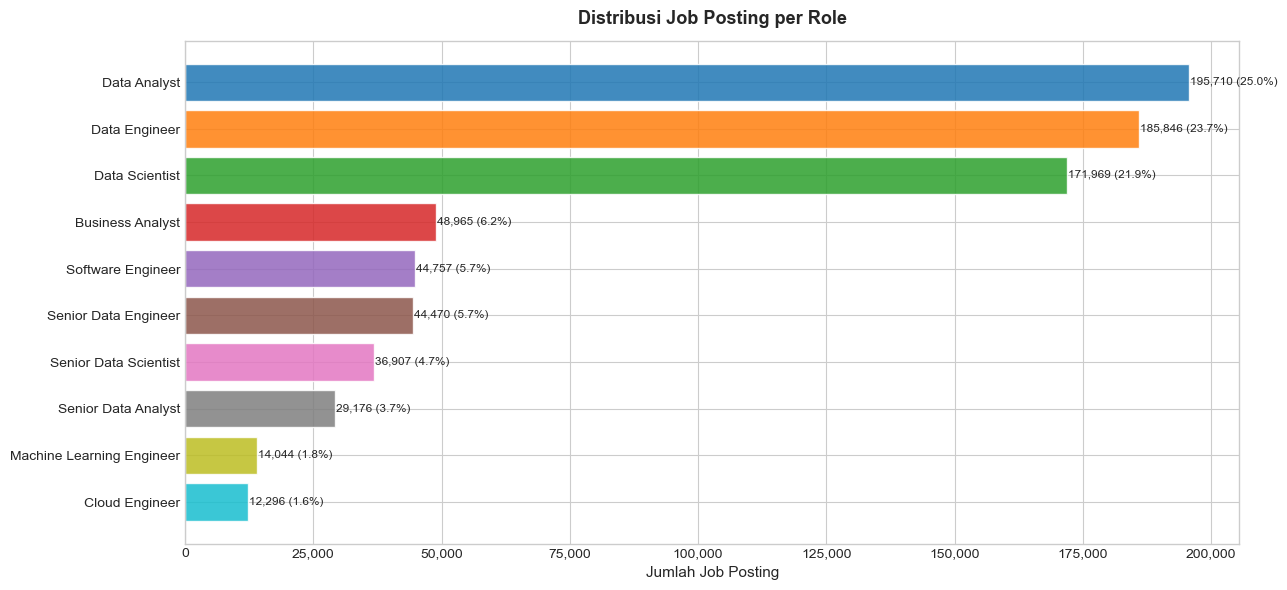

,count,pct
job_title_short,,
Data Analyst,195710,24.9600
Data Engineer,185846,23.7000
Data Scientist,171969,21.9300
Business Analyst,48965,6.2400
Software Engineer,44757,5.7100
Senior Data Engineer,44470,5.6700
Senior Data Scientist,36907,4.7100
Senior Data Analyst,29176,3.7200
Machine Learning Engineer,14044,1.7900


In [ ]:
# ==================================================
# 6. EXPLORATORY DATA ANALYSIS
# ==================================================

#---------------------------------------------------
# 6.1 Distribusi Role
#---------------------------------------------------
role_counts = df['job_title_short'].value_counts()
role_pct    = (role_counts / len(df) * 100).round(2)
colors_role = list(plt.cm.tab10.colors[:len(role_counts)])

fig, ax = plt.subplots(figsize=FIGSIZE_STD)
bars = ax.barh(role_counts.index[::-1], role_counts.values[::-1],
               color=colors_role[::-1], alpha=0.85, edgecolor='white')
ax.set_title('Distribusi Job Posting per Role', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Jumlah Job Posting', fontsize=11)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{int(x):,}'))

for bar, count, pct in zip(bars, role_counts.values[::-1], role_pct.values[::-1]):
    ax.text(bar.get_width() + 200, bar.get_y() + bar.get_height() / 2,
            f'{count:,} ({pct:.1f}%)', va='center', fontsize=8.5)

plt.tight_layout()
plt.savefig('plot_role_distribution.png', dpi=DPI, bbox_inches='tight')
plt.show()

display(pd.DataFrame({'count': role_counts, 'pct': role_pct}))

Saving -> ../outputs/figures\plot_geo_distribution.png


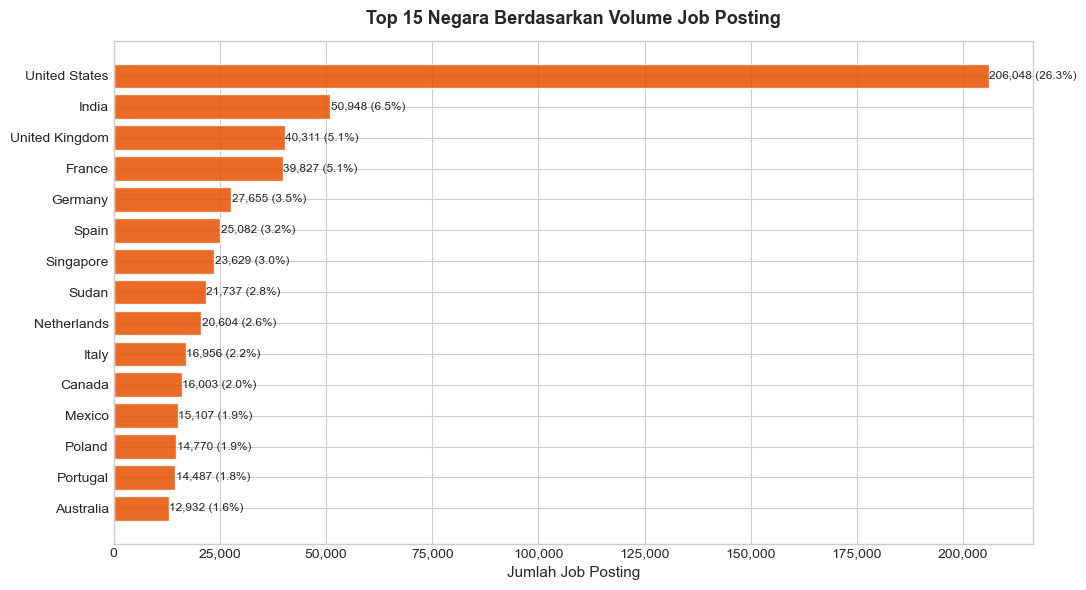

Konsentrasi United States: 26.3%


In [ ]:
#---------------------------------------------------
# 6.2 Distribusi Geografis
#---------------------------------------------------
country_counts = df['job_country'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(country_counts.index[::-1], country_counts.values[::-1],
               color=COLOR_ACCENT, alpha=0.85, edgecolor='white')
ax.set_title('Top 15 Negara Berdasarkan Volume Job Posting', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Jumlah Job Posting', fontsize=11)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{int(x):,}'))

for bar, val in zip(bars, country_counts.values[::-1]):
    pct = val / len(df) * 100
    ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height() / 2,
            f'{val:,} ({pct:.1f}%)', va='center', fontsize=8.5)

plt.tight_layout()
plt.savefig('plot_geo_distribution.png', dpi=DPI, bbox_inches='tight')
plt.show()

us_pct = country_counts.get('United States', 0) / len(df) * 100
print(f"Konsentrasi United States: {us_pct:.1f}%")

Distribusi geografis mengkonfirmasi karakter US-centric dari dataset ini. Persentase konsentrasi di United States yang tinggi berarti insight yang dihasilkan paling valid untuk pasar kerja data analytics di Amerika Serikat.

Saving -> ../outputs/figures\plot_top_skills_overall.png


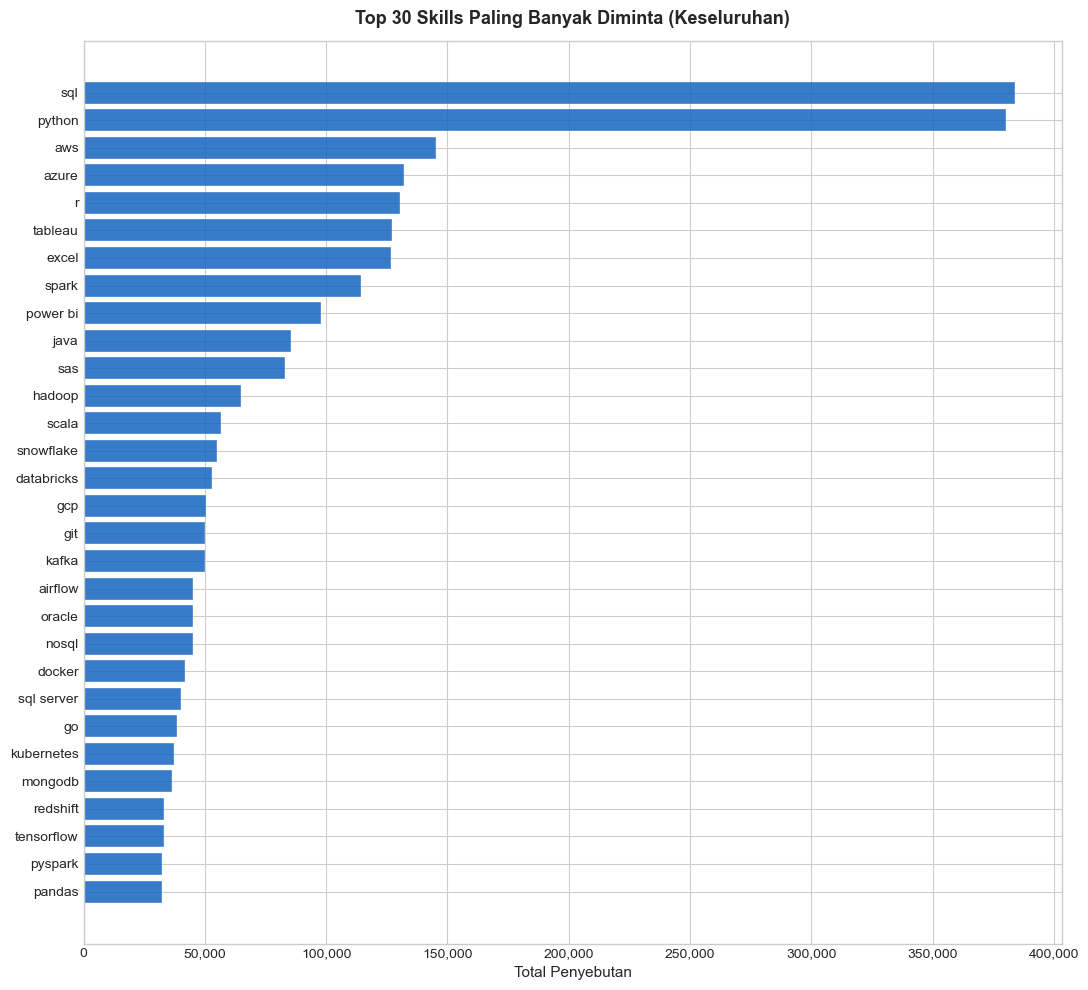

Top 10 skills keseluruhan:
skill
sql         384084
python      380158
aws         145089
azure       132271
r           130650
tableau     126984
excel       126814
spark       114400
power bi     97956
java         85402


In [ ]:
#---------------------------------------------------
# 6.3 Skill Landscape Overview (Top Skills Keseluruhan)
#---------------------------------------------------
top_skills_overall = df_skills_long['skill'].value_counts().head(TOP_N_SKILLS_EDA)

fig, ax = plt.subplots(figsize=(11, 10))
ax.barh(top_skills_overall.index[::-1], top_skills_overall.values[::-1],
        color=COLOR_RISING, alpha=0.85, edgecolor='white', linewidth=0.3)
ax.set_title(f'Top {TOP_N_SKILLS_EDA} Skills Paling Banyak Diminta (Keseluruhan)',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Total Penyebutan', fontsize=11)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('plot_top_skills_overall.png', dpi=DPI, bbox_inches='tight')
plt.show()

print("Top 10 skills keseluruhan:")
print(top_skills_overall.head(10).to_string())

Grafik ini adalah baseline skill landscape. Skill yang mendominasi di sini cenderung muncul di hampir semua role (seperti SQL dan Python) dan memiliki IDF rendah yang artinya mereka tidak informatif sebagai differentiator. Untuk menemukan skill yang benar-benar khas per role, diperlukan TF-IDF adapted score di Section 10.

Saving -> ../outputs/figures\plot_skill_count_dist.png


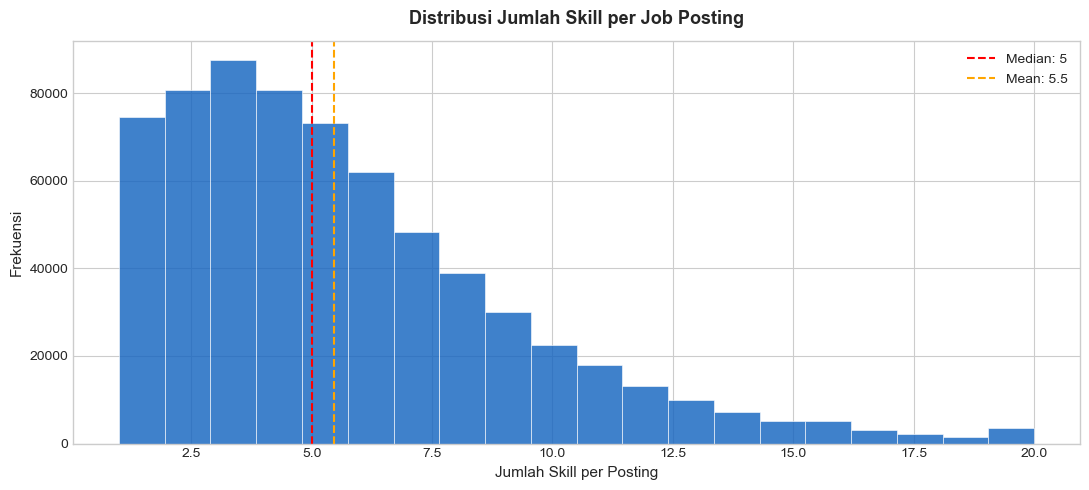

Posting tanpa skill  : 116,740 (14.9%)
Median skill/posting : 5
Mean skill/posting   : 5.5


In [ ]:
#---------------------------------------------------
# 6.4 Distribusi Jumlah Skill per Posting
#---------------------------------------------------
skill_cnt_capped = df['skill_count'].clip(upper=20)

fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(skill_cnt_capped[skill_cnt_capped > 0], bins=20,
        color=COLOR_RISING, alpha=0.82, edgecolor='white', linewidth=0.5)

median_cnt = df[df['skill_count'] > 0]['skill_count'].median()
mean_cnt   = df[df['skill_count'] > 0]['skill_count'].mean()
ax.axvline(median_cnt, color='red',    linestyle='--', linewidth=1.5, label=f'Median: {median_cnt:.0f}')
ax.axvline(mean_cnt,   color='orange', linestyle='--', linewidth=1.5, label=f'Mean: {mean_cnt:.1f}')
ax.set_title('Distribusi Jumlah Skill per Job Posting', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Jumlah Skill per Posting', fontsize=11)
ax.set_ylabel('Frekuensi', fontsize=11)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('plot_skill_count_dist.png', dpi=DPI, bbox_inches='tight')
plt.show()

pct_no_skill = (df['skill_count'] == 0).sum() / len(df) * 100
print(f"Posting tanpa skill  : {(df['skill_count'] == 0).sum():,} ({pct_no_skill:.1f}%)")
print(f"Median skill/posting : {median_cnt:.0f}")
print(f"Mean skill/posting   : {mean_cnt:.1f}")

Distribusi jumlah skill per posting adalah pra-syarat kelayakan analisis co-occurrence. Jika mayoritas posting memiliki kurang dari 2 skill, maka tidak ada pair yang bisa dibentuk dan network akan kosong. Median dan mean skill per posting yang tersedia menjadi indikator utama kualitas ekstrasi skill.

Saving -> ../outputs/figures\plot_role_over_time.png


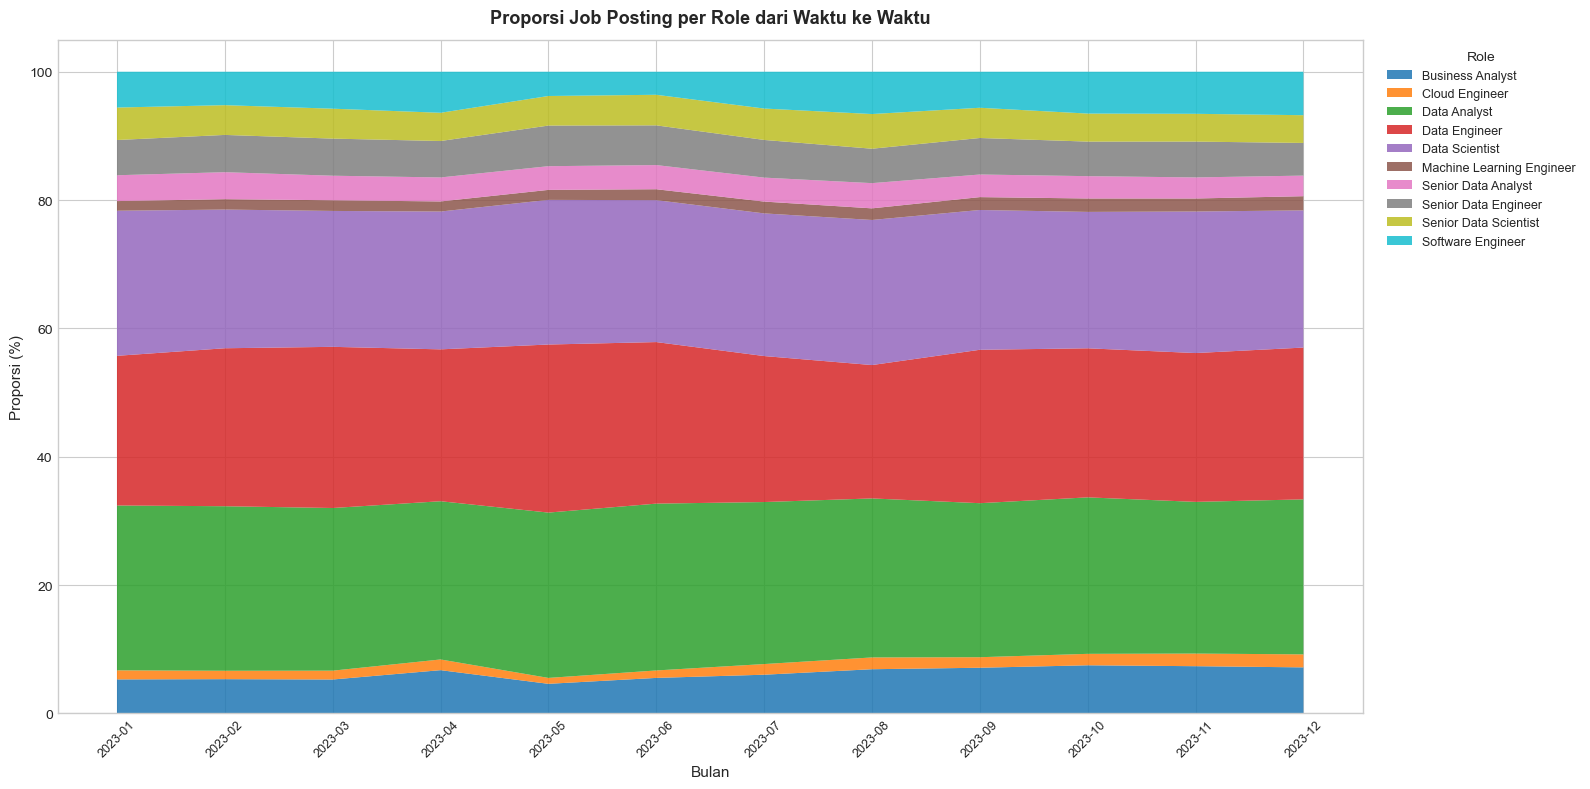

In [ ]:
#---------------------------------------------------
# 6.5 Distribusi Role dari Waktu ke Waktu (Stacked Area)
#---------------------------------------------------
df_valid_time = df[df['year_month'].isin(valid_months)].copy()
role_monthly  = df_valid_time.groupby(['year_month', 'job_title_short']).size().unstack(fill_value=0)
role_monthly_pct = role_monthly.div(role_monthly.sum(axis=1), axis=0) * 100
role_monthly_pct.index = role_monthly_pct.index.astype(str)

fig, ax = plt.subplots(figsize=FIGSIZE_WIDE)
colors_stack = list(plt.cm.tab10.colors)
ax.stackplot(
    role_monthly_pct.index,
    [role_monthly_pct[c] for c in role_monthly_pct.columns],
    labels=role_monthly_pct.columns,
    colors=colors_stack[:len(role_monthly_pct.columns)],
    alpha=0.85
)
ax.set_title('Proporsi Job Posting per Role dari Waktu ke Waktu',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Bulan', fontsize=11)
ax.set_ylabel('Proporsi (%)', fontsize=11)
ax.tick_params(axis='x', rotation=45, labelsize=9)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9, title='Role')
plt.tight_layout()
plt.savefig('plot_role_over_time.png', dpi=DPI, bbox_inches='tight')
plt.show()

Stacked area chart ini menampilkan apakah komposisi role di pasar kerja data bergeser selama 2023. Jika proporsi role tertentu terlihat naik secara konsisten di paruh kedua tahun, itu bisa menjadi sinyal perubahan prioritas hiring.

## **`[7]` Temporal Skill Demand Analysis**

Ini adalah analisis inti Layer 1. Temporal Frequency Analysis (TFA) menggunakan proporsi (%) bukan count absolut untuk mengontrol fluktuasi volume posting bulanan akibat seasonality hiring. Setiap data poin merepresentasikan: *"dari semua job posting di bulan X, berapa persen yang menyebut skill Y?"*

In [ ]:
# ==================================================
# 7. TEMPORAL SKILL DEMAND ANALYSIS
# ==================================================

#---------------------------------------------------
# 7.1 Build Monthly Skill Proportion Matrix
#---------------------------------------------------
# Denominator: total posting per bulan
monthly_totals = (
    df[df['year_month'].isin(valid_months)]
    .groupby('year_month')
    .size()
    .reset_index(name='total_postings')
)

# Numerator: skill count per bulan per skill
monthly_skill_raw = (
    df_skills_long[df_skills_long['year_month'].isin(valid_months)]
    .groupby(['year_month', 'skill'])
    .size()
    .reset_index(name='skill_count')
)

# Proporsi (normalized by monthly total)
monthly_skill_prop = monthly_skill_raw.merge(monthly_totals, on='year_month')
monthly_skill_prop['proportion_pct'] = (
    monthly_skill_prop['skill_count'] / monthly_skill_prop['total_postings'] * 100
)

# Top skills berdasarkan frekuensi keseluruhan
top_skills_for_trend = (
    df_skills_long['skill']
    .value_counts()
    .head(TOP_N_SKILLS_TREND)
    .index.tolist()
)

print(f"Matrix temporal selesai.")
print(f"  Dimensi           : {monthly_skill_prop.shape}")
print(f"  Skill unik        : {monthly_skill_prop['skill'].nunique():,}")
print(f"  Bulan valid       : {len(valid_months)}")
print(f"  Top {TOP_N_SKILLS_TREND} skills yang dicari: {top_skills_for_trend}")

Matrix temporal selesai.
  Dimensi           : (2853, 5)
  Skill unik        : 252
  Bulan valid       : 12
  Top 10 skills yang dicari: ['sql', 'python', 'aws', 'azure', 'r', 'tableau', 'excel', 'spark', 'power bi', 'java']


Saving -> ../outputs/figures\plot_skill_trend_line.png


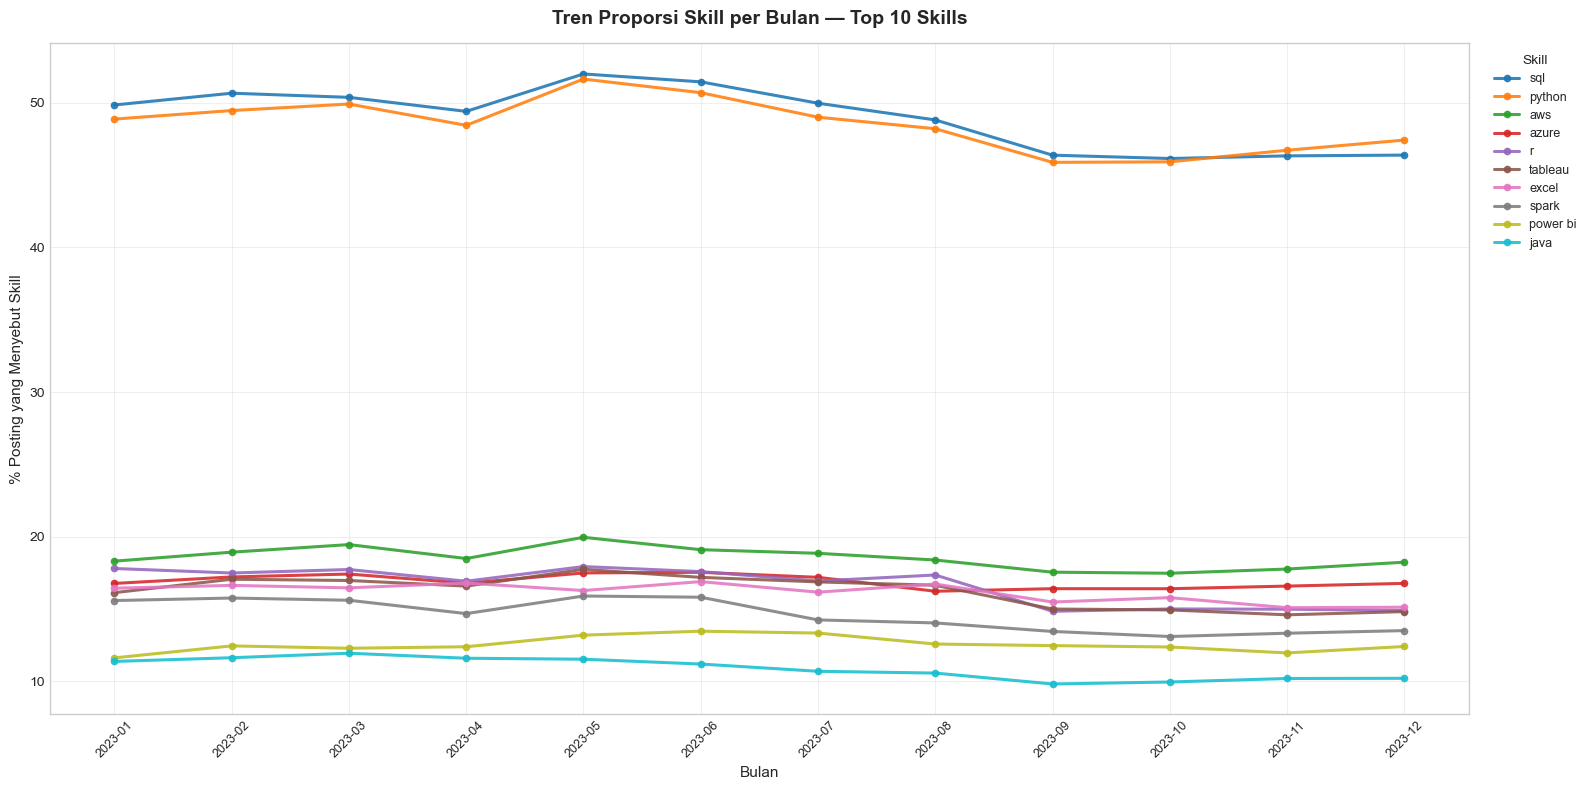

In [ ]:
#---------------------------------------------------
# 7.2 Multi-line Chart: Tren Skill per Bulan
#---------------------------------------------------
trend_pivot = monthly_skill_prop[
    monthly_skill_prop['skill'].isin(top_skills_for_trend)
].pivot(index='year_month', columns='skill', values='proportion_pct')
trend_pivot.index = trend_pivot.index.astype(str)

fig, ax = plt.subplots(figsize=FIGSIZE_WIDE)
colors_trend = list(plt.cm.tab10.colors)

for i, skill in enumerate(top_skills_for_trend):
    if skill in trend_pivot.columns:
        ax.plot(
            trend_pivot.index,
            trend_pivot[skill],
            label=skill,
            color=colors_trend[i % 10],
            linewidth=2.2,
            marker='o',
            markersize=4.5,
            alpha=0.88
        )

ax.set_title(f'Tren Proporsi Skill per Bulan — Top {TOP_N_SKILLS_TREND} Skills',
             fontsize=14, fontweight='bold', pad=14)
ax.set_xlabel('Bulan', fontsize=11)
ax.set_ylabel('% Posting yang Menyebut Skill', fontsize=11)
ax.tick_params(axis='x', rotation=45, labelsize=9)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9, title='Skill')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plot_skill_trend_line.png', dpi=DPI, bbox_inches='tight')
plt.show()

Setiap garis mewakili satu skill, dan posisi vertikal pada setiap titik menunjukkan berapa persen posting di bulan tersebut meminta skill itu. Garis yang konsisten naik dari kiri ke kanan mencerminkan skill dengan momentum positif. Garis yang turun menandai skill yang mulai berkurang relevansinya di pasar.

Skala y adalah proporsi (%), bukan count absolut. Skill yang terlihat "naik" bukan karena posting bertambah di bulan itu, tetapi karena proporsi posting yang meminta skill tersebut memang meningkat.

Saving -> ../outputs/figures\plot_category_trend.png


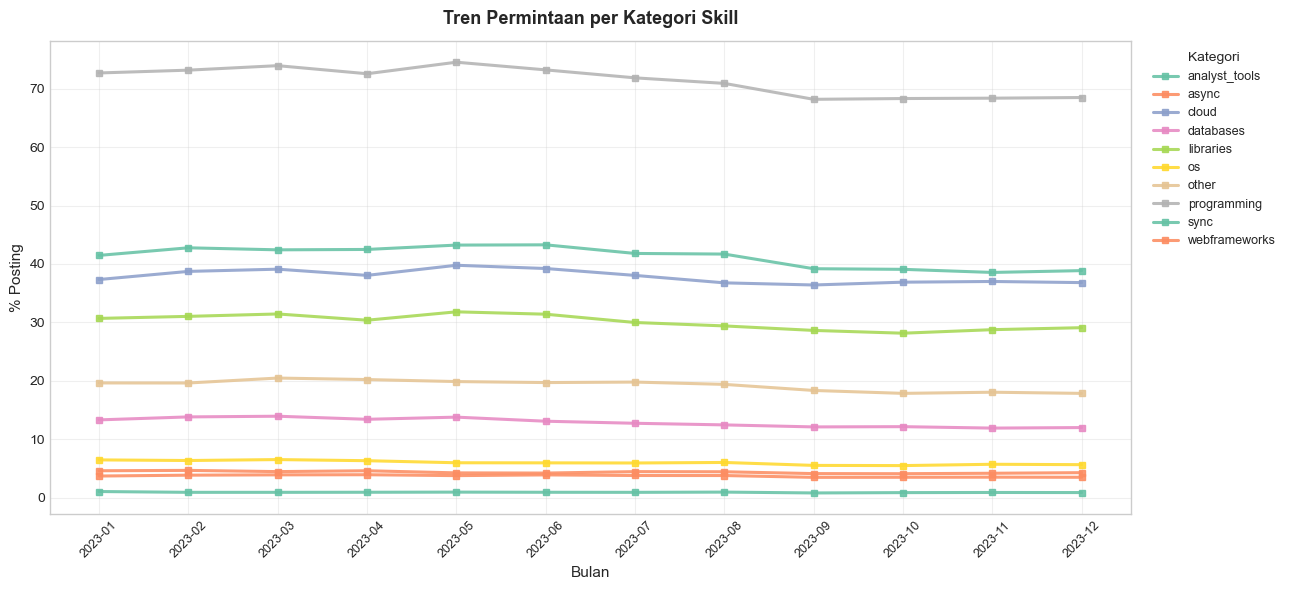

In [ ]:
#---------------------------------------------------
# 7.3 Skill Category Trend (dari job_type_skills)
#---------------------------------------------------
category_rows = []
df_with_type  = df[df['type_skills_parsed'].apply(lambda x: isinstance(x, dict) and len(x) > 0)].copy()

for _, row in df_with_type.iterrows():
    if row['year_month'] not in valid_months:
        continue
    for category in row['type_skills_parsed'].keys():
        skills_in_cat = row['type_skills_parsed'][category]
        if isinstance(skills_in_cat, list) and len(skills_in_cat) > 0:
            category_rows.append({
                'year_month': row['year_month'],
                'category'  : str(category).lower()
            })

df_category = pd.DataFrame(category_rows)

if not df_category.empty:
    cat_monthly = df_category.groupby(['year_month', 'category']).size().reset_index(name='count')
    cat_monthly = cat_monthly.merge(monthly_totals, on='year_month')
    cat_monthly['proportion_pct'] = cat_monthly['count'] / cat_monthly['total_postings'] * 100

    cat_pivot = cat_monthly.pivot(index='year_month', columns='category', values='proportion_pct').fillna(0)
    cat_pivot.index = cat_pivot.index.astype(str)

    fig, ax = plt.subplots(figsize=FIGSIZE_STD)
    colors_cat = list(plt.cm.Set2.colors)
    for i, cat in enumerate(cat_pivot.columns):
        ax.plot(cat_pivot.index, cat_pivot[cat],
                label=cat, color=colors_cat[i % len(colors_cat)],
                linewidth=2.2, marker='s', markersize=4, alpha=0.88)

    ax.set_title('Tren Permintaan per Kategori Skill', fontsize=13, fontweight='bold', pad=12)
    ax.set_xlabel('Bulan', fontsize=11)
    ax.set_ylabel('% Posting', fontsize=11)
    ax.tick_params(axis='x', rotation=45, labelsize=9)
    ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9, title='Kategori')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('plot_category_trend.png', dpi=DPI, bbox_inches='tight')
    plt.show()
else:
    print("[INFO] Data kategori skill tidak tersedia atau kosong. Section ini dilewati.")

Tren per kategori memberikan perspektif bukan skill individual, melainkan keluarga skill (cloud, databases, programming, libraries) yang dibandingkan. Ini berguna untuk melihat apakah pasar bergerak lebih ke arah cloud-native tooling atau tetap mempertahankan permintaan tinggi untuk skill SQL dan programming klasik sepanjang 2023.

## **`[8]` Skill Emergence dan Decline Detection**

Section ini mendeteksi skill yang secara statistik mengalami perubahan proporsi signifikan antara H1 (Januari-Juni) dan H2 (Juli-Desember) 2023. Chi-Square Proportional Test digunakan untuk memisahkan sinyal dari fluktuasi sampling, dan minimum frequency threshold diterapkan untuk menghindari distorsi dari skill dengan volume sangat kecil.

In [ ]:
# ==================================================
# 8. SKILL EMERGENCE DAN DECLINE DETECTION
# ==================================================

#---------------------------------------------------
# 8.1 Definisi Periode H1 dan H2
#---------------------------------------------------
h1_months = [m for m in valid_months if m.month <= 6]
h2_months = [m for m in valid_months if m.month > 6]

print(f"H1 (Jan-Jun) : {len(h1_months)} bulan — {[str(m) for m in h1_months]}")
print(f"H2 (Jul-Des) : {len(h2_months)} bulan — {[str(m) for m in h2_months]}")

df_h1      = df[df['year_month'].isin(h1_months)]
df_h2      = df[df['year_month'].isin(h2_months)]
skills_h1  = df_skills_long[df_skills_long['year_month'].isin(h1_months)]
skills_h2  = df_skills_long[df_skills_long['year_month'].isin(h2_months)]

n_post_h1  = len(df_h1)
n_post_h2  = len(df_h2)
skill_cnt_h1 = skills_h1['skill'].value_counts()
skill_cnt_h2 = skills_h2['skill'].value_counts()
skill_prop_h1 = skill_cnt_h1 / n_post_h1
skill_prop_h2 = skill_cnt_h2 / n_post_h2

print(f"\nTotal posting H1 : {n_post_h1:,}")
print(f"Total posting H2 : {n_post_h2:,}")

#---------------------------------------------------
# 8.2 Growth Rate + Chi-Square Test
#---------------------------------------------------
all_common = set(skill_cnt_h1.index) & set(skill_cnt_h2.index)
qualified  = [s for s in all_common
              if (skill_cnt_h1.get(s, 0) + skill_cnt_h2.get(s, 0)) >= MIN_SKILL_FREQ]

print(f"Skill dengan total freq >= {MIN_SKILL_FREQ}: {len(qualified)}")
print("Menghitung growth rate dan chi-square test...")

growth_records = []
for skill in qualified:
    c1  = int(skill_cnt_h1.get(skill, 0))
    c2  = int(skill_cnt_h2.get(skill, 0))
    p1  = float(skill_prop_h1.get(skill, 0))
    p2  = float(skill_prop_h2.get(skill, 0))
    growth_rate = (p2 - p1) / p1 * 100 if p1 > 0 else 0.0

    contingency = [[c1, max(0, n_post_h1 - c1)], [c2, max(0, n_post_h2 - c2)]]
    try:
        _, p_val, _, _ = chi2_contingency(contingency)
    except Exception:
        p_val = 1.0

    growth_records.append({
        'skill'          : skill,
        'prop_h1_pct'    : round(p1 * 100, 3),
        'prop_h2_pct'    : round(p2 * 100, 3),
        'count_h1'       : c1,
        'count_h2'       : c2,
        'growth_rate_pct': round(growth_rate, 2),
        'p_value'        : round(p_val, 6),
        'significant'    : p_val < 0.05,
        'direction'      : 'Rising' if growth_rate > 0 else 'Declining'
    })

df_growth = (pd.DataFrame(growth_records)
               .sort_values('growth_rate_pct', ascending=False)
               .reset_index(drop=True))

sig_rising    = df_growth[(df_growth['significant']) & (df_growth['growth_rate_pct'] > 0)].shape[0]
sig_declining = df_growth[(df_growth['significant']) & (df_growth['growth_rate_pct'] < 0)].shape[0]
not_sig       = df_growth[~df_growth['significant']].shape[0]

print(f"\n=== HASIL GROWTH RATE ANALYSIS ===")
print(f"Skill signifikan naik    : {sig_rising}")
print(f"Skill signifikan turun   : {sig_declining}")
print(f"Skill tidak signifikan   : {not_sig}")

print("\nTop 10 Rising Skills (p < 0.05):")
display(df_growth[df_growth['significant'] & (df_growth['growth_rate_pct'] > 0)].head(10)[
    ['skill', 'prop_h1_pct', 'prop_h2_pct', 'growth_rate_pct', 'p_value']
])
print("\nTop 10 Declining Skills (p < 0.05):")
display(df_growth[df_growth['significant'] & (df_growth['growth_rate_pct'] < 0)].tail(10)[
    ['skill', 'prop_h1_pct', 'prop_h2_pct', 'growth_rate_pct', 'p_value']
])

H1 (Jan-Jun) : 6 bulan — ['2023-01', '2023-02', '2023-03', '2023-04', '2023-05', '2023-06']
H2 (Jul-Des) : 6 bulan — ['2023-07', '2023-08', '2023-09', '2023-10', '2023-11', '2023-12']

Total posting H1 : 396,745
Total posting H2 : 387,395
Skill dengan total freq >= 500: 162
Menghitung growth rate dan chi-square test...

=== HASIL GROWTH RATE ANALYSIS ===
Skill signifikan naik    : 17
Skill signifikan turun   : 95
Skill tidak signifikan   : 50

Top 10 Rising Skills (p < 0.05):


,skill,prop_h1_pct,prop_h2_pct,growth_rate_pct,p_value
0,hugging face,0.0900,0.1610,78.2200,0.0000
1,ubuntu,0.1290,0.1860,43.9400,0.0000
2,unity,0.1950,0.2360,21.0700,0.0001
3,microsoft teams,0.0850,0.1030,20.5400,0.0125
4,openstack,0.0910,0.1090,18.7800,0.0177
5,vmware,0.3260,0.3810,16.8200,0.0000
6,phoenix,0.2100,0.2430,15.5400,0.0025
7,nltk,0.2970,0.3360,13.2800,0.0020
9,pytorch,3.2730,3.6730,12.2300,0.0000
10,fastapi,0.2680,0.3000,11.7400,0.0093



Top 10 Declining Skills (p < 0.05):


,skill,prop_h1_pct,prop_h2_pct,growth_rate_pct,p_value
152,opencv,0.3120,0.2440,-21.9700,0.0000
153,terminal,0.2420,0.1850,-23.5400,0.0000
154,node.js,0.4420,0.3360,-23.9500,0.0000
155,visio,0.7690,0.5800,-24.6400,0.0000
156,ggplot2,0.1870,0.1410,-24.7800,0.0000
157,theano,0.1290,0.0950,-26.3000,0.0000
158,rshiny,0.1140,0.0830,-27.5900,0.0000
159,vue,0.4380,0.3090,-29.4100,0.0000
160,watson,0.1440,0.0950,-34.0000,0.0000
161,datarobot,0.1310,0.0730,-44.5500,0.0000


Tabel di atas memisahkan skill ke tiga kategori berdasarkan output chi-square test. Skill yang masuk kategori "signifikan naik" adalah yang perubahannya melampaui ambang statistik (p < 0.05), artinya perubahan proporsi tersebut sangat kecil kemungkinannya terjadi karena kebetulan sampling.

Jumlah skill per kategori (signifikan naik, signifikan turun, tidak signifikan) yang muncul di output memberikan gambaran seberapa dinamis pasar skill data analytics di 2023. Semakin banyak skill yang bergerak secara signifikan, semakin "volatile" pasar tersebut.

Saving -> ../outputs/figures\plot_skill_diverging.png


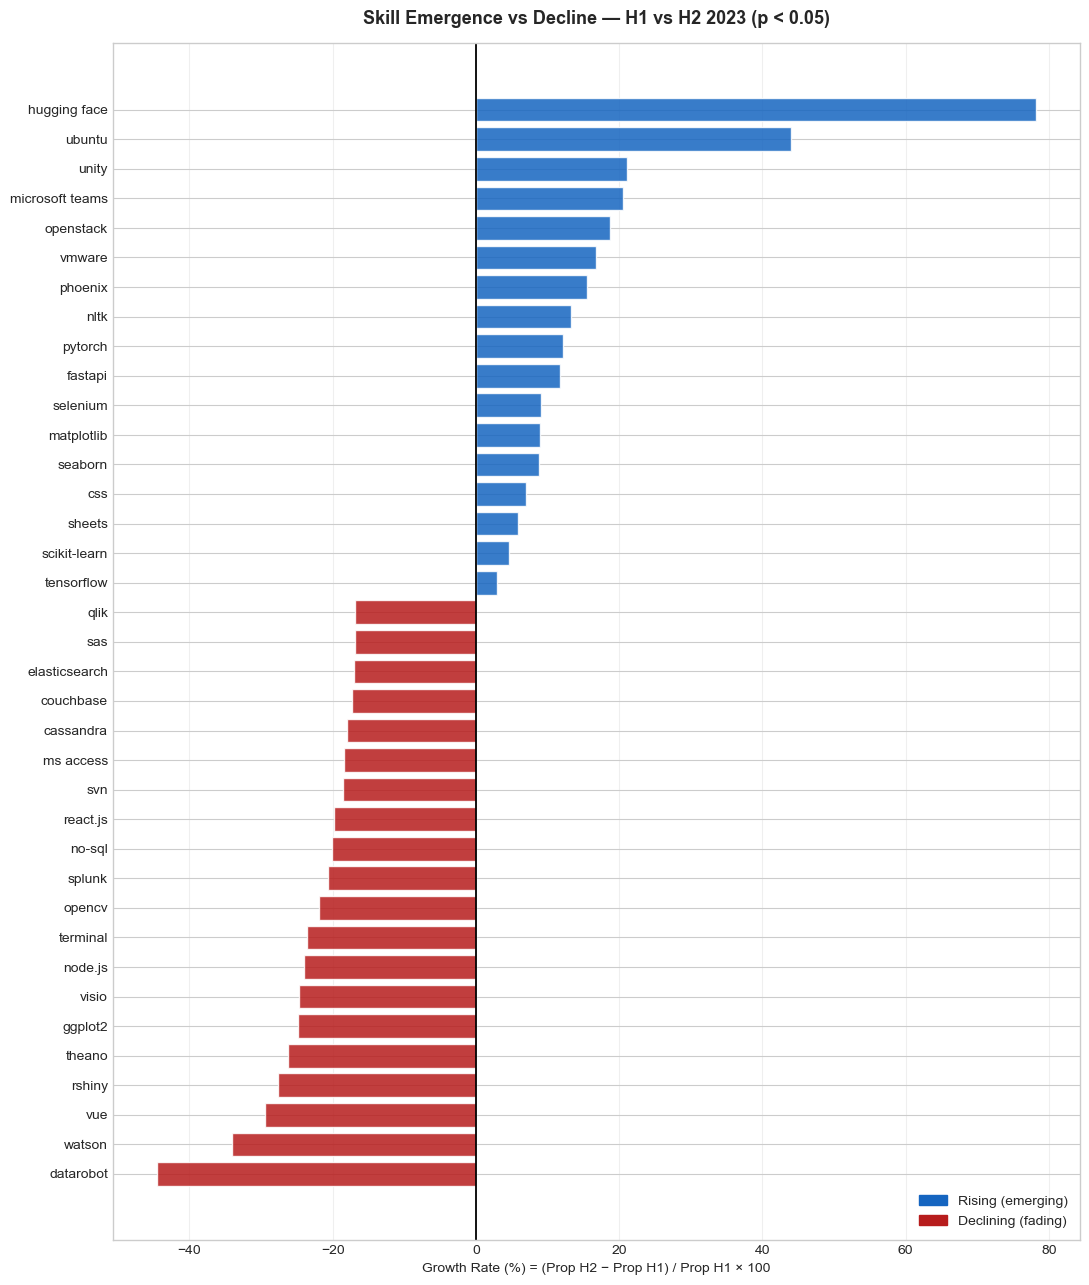

In [ ]:
#---------------------------------------------------
# 8.3 Diverging Bar Chart: Emerging vs Declining
#---------------------------------------------------
sig_df        = df_growth[df_growth['significant']].copy()
top_rising    = sig_df[sig_df['growth_rate_pct'] > 0].head(20)
top_declining = sig_df[sig_df['growth_rate_pct'] < 0].tail(20)
plot_df       = pd.concat([top_declining, top_rising]).sort_values('growth_rate_pct', ascending=True)

colors_div = [COLOR_RISING if g > 0 else COLOR_DECLINING for g in plot_df['growth_rate_pct']]

fig, ax = plt.subplots(figsize=(11, max(9, len(plot_df) * 0.35)))
ax.barh(plot_df['skill'], plot_df['growth_rate_pct'],
        color=colors_div, alpha=0.85, edgecolor='white')
ax.axvline(0, color='black', linewidth=1.3)
ax.set_title('Skill Emergence vs Decline — H1 vs H2 2023 (p < 0.05)',
             fontsize=13, fontweight='bold', pad=14)
ax.set_xlabel('Growth Rate (%) = (Prop H2 − Prop H1) / Prop H1 × 100', fontsize=10)
ax.legend(handles=[
    mpatches.Patch(color=COLOR_RISING,   label='Rising (emerging)'),
    mpatches.Patch(color=COLOR_DECLINING, label='Declining (fading)')
], fontsize=10, loc='lower right')
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('plot_skill_diverging.png', dpi=DPI, bbox_inches='tight')
plt.show()

Saving -> ../outputs/figures\plot_skill_opportunity_matrix.png


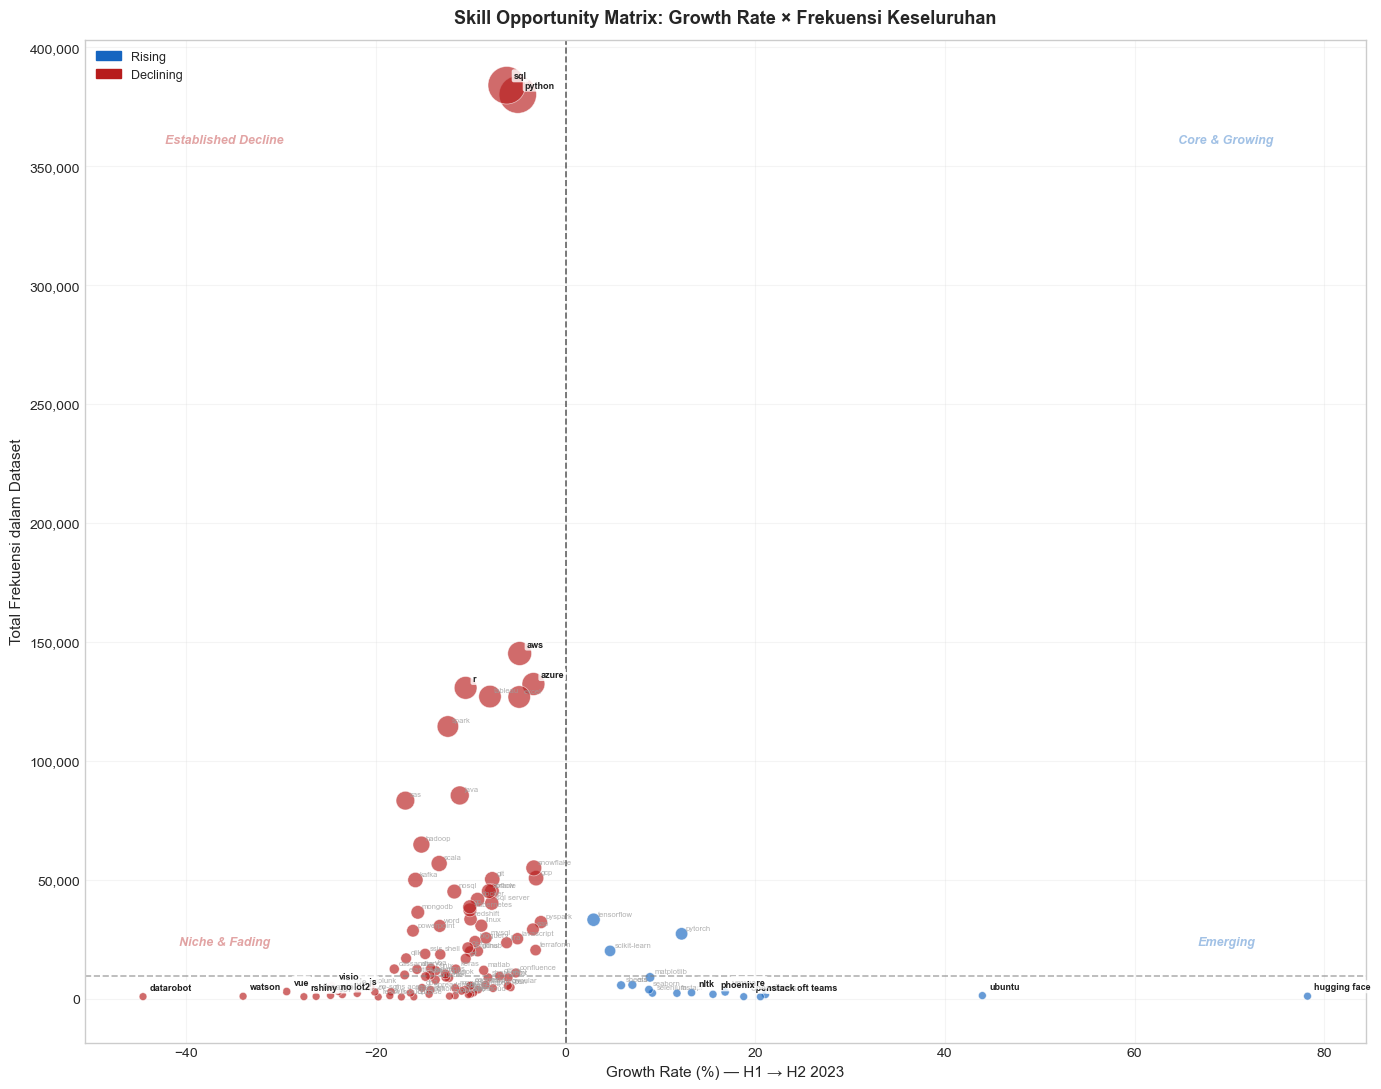

In [ ]:
#---------------------------------------------------
# 8.4 Skill Opportunity Bubble Chart
#---------------------------------------------------
total_freq        = df_skills_long['skill'].value_counts().reset_index()
total_freq.columns = ['skill', 'total_count']
df_growth_viz     = df_growth[df_growth['significant']].merge(total_freq, on='skill', how='left')

if not df_growth_viz.empty:
    scatter_colors = [COLOR_RISING if g > 0 else COLOR_DECLINING
                      for g in df_growth_viz['growth_rate_pct']]
    max_count     = df_growth_viz['total_count'].max()
    scatter_sizes = (df_growth_viz['total_count'] / max_count * 700 + 30).tolist()

    fig, ax = plt.subplots(figsize=(14, 11))
    ax.scatter(
        df_growth_viz['growth_rate_pct'],
        df_growth_viz['total_count'],
        c=scatter_colors, s=scatter_sizes, alpha=0.65,
        edgecolors='white', linewidth=0.5, zorder=2
    )

    # Garis referensi
    ax.axvline(0, color='black', linewidth=1.2, linestyle='--', alpha=0.6)
    med_freq = df_growth_viz['total_count'].median()
    ax.axhline(med_freq, color='gray', linewidth=1.2, linestyle='--',
               alpha=0.6, label=f'Median freq ({int(med_freq):,})')

    # Definisi extreme skills (paling menarik secara analitis)
    extreme_skills = set(
        pd.concat([
            df_growth_viz.nlargest(8, 'growth_rate_pct'),
            df_growth_viz.nsmallest(8, 'growth_rate_pct'),
            df_growth_viz.nlargest(5, 'total_count'),
        ])['skill'].tolist()
    )

    # Layer 1 — Label semua dot: font kecil, abu-abu, tanpa bbox
    for _, row in df_growth_viz.iterrows():
        if row['skill'] not in extreme_skills:
            ax.annotate(
                row['skill'],
                (row['growth_rate_pct'], row['total_count']),
                fontsize=5.5, color='#9E9E9E', alpha=0.80,
                xytext=(3, 3), textcoords='offset points',
                zorder=3
            )

    # Layer 2 — Label extreme skills: font besar, bold, dengan bbox putih
    for _, row in df_growth_viz[df_growth_viz['skill'].isin(extreme_skills)].iterrows():
        ax.annotate(
            row['skill'],
            (row['growth_rate_pct'], row['total_count']),
            fontsize=6.5, fontweight='bold', color='#212121',
            xytext=(5, 5), textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.22', fc='white', alpha=0.80, ec='none'),
            zorder=4
        )

    # Quadrant labels — posisi dari range data aktual
    x_min = df_growth_viz['growth_rate_pct'].min()
    x_max = df_growth_viz['growth_rate_pct'].max()
    y_min = df_growth_viz['total_count'].min()
    y_max = df_growth_viz['total_count'].max()
    x_pad = (x_max - x_min) * 0.07
    y_pad = (y_max - y_min) * 0.06

    quadrant_labels = [
        ('Core & Growing',      x_max - x_pad, y_max - y_pad, COLOR_RISING),
        ('Emerging',            x_max - x_pad, y_min + y_pad, COLOR_RISING),
        ('Established Decline', x_min + x_pad, y_max - y_pad, COLOR_DECLINING),
        ('Niche & Fading',      x_min + x_pad, y_min + y_pad, COLOR_DECLINING),
    ]
    for label, tx, ty, col in quadrant_labels:
        ax.text(tx, ty, label, fontsize=9, alpha=0.40, ha='center',
                va='center', color=col, fontstyle='italic', fontweight='bold')

    ax.set_title('Skill Opportunity Matrix: Growth Rate × Frekuensi Keseluruhan',
                 fontsize=13, fontweight='bold', pad=12)
    ax.set_xlabel('Growth Rate (%) — H1 → H2 2023', fontsize=11)
    ax.set_ylabel('Total Frekuensi dalam Dataset', fontsize=11)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{int(x):,}'))
    ax.legend(handles=[
        mpatches.Patch(color=COLOR_RISING,    label='Rising'),
        mpatches.Patch(color=COLOR_DECLINING, label='Declining'),
    ], fontsize=9, loc='upper left')
    ax.grid(True, alpha=0.20)

    plt.tight_layout()
    plt.savefig('plot_skill_opportunity_matrix.png', dpi=DPI, bbox_inches='tight')
    plt.show()

else:
    print("[INFO] df_growth_viz kosong, bubble chart dilewati.")

Bubble chart ini merangkum seluruh analisis emergence/decline dalam satu visualisasi strategis. Posisi horizontal menunjukkan arah dan besarnya momentum (kanan = naik, kiri = turun), posisi vertikal menunjukkan seberapa umum skill tersebut di pasar, dan ukuran titik juga mencerminkan total frekuensi.

Keempat kuadran memiliki implikasi berbeda. Skill di **Core & Growing** (kanan atas) adalah investasi paling aman, sudah banyak diminta dan masih terus naik. Skill di **Emerging** (kanan bawah) adalah peluang early investment. Skill di **Established Decline** (kiri atas) masih relevan untuk jangka pendek tapi mulai melemah. Skill di **Niche & Fading** (kiri bawah) adalah prioritas terendah untuk pengembangan karier.

## **`[9]` Skill Co-occurrence Network Analysis**

Network ini memvisualisasikan ekosistem dua skill yang sering muncul bersama dalam satu posting membentuk edge. PMI (Pointwise Mutual Information) digunakan sebagai bobot edge untuk mengukur seberapa "mengejutkan" kemunculan bersama dua skill yang mengimbangi dominasi skill yang sangat umum. Louvain community detection menemukan cluster organik, dan betweenness centrality mengidentifikasi bridge skills.

In [ ]:
# ==================================================
# 9. SKILL CO-OCCURRENCE NETWORK ANALYSIS
# ==================================================

#---------------------------------------------------
# 9.1 Persiapan Top Skills untuk Network
#---------------------------------------------------
top_skills_net = (
    df_skills_long['skill']
    .value_counts()
    .head(TOP_N_SKILLS_NET)
    .index.tolist()
)
top_skills_set = set(top_skills_net)

print(f"Top {TOP_N_SKILLS_NET} skills dipilih untuk network.")
print(f"Contoh: {top_skills_net[:8]}...")

#---------------------------------------------------
# 9.2 Build Co-occurrence Counter
#---------------------------------------------------
print(f"\nMembangun co-occurrence matrix...")
cooccurrence_counter = Counter()
skill_doc_count      = Counter()
n_docs_processed     = 0

df_for_net = df[df['skills_parsed'].apply(lambda x: isinstance(x, list) and len(x) >= 2)].copy()

for idx, skills in enumerate(df_for_net['skills_parsed']):
    filtered = list(set([s for s in skills if s in top_skills_set]))
    if len(filtered) < 2:
        continue
    n_docs_processed += 1
    for s in filtered:
        skill_doc_count[s] += 1
    for pair in itertools.combinations(sorted(filtered), 2):
        cooccurrence_counter[pair] += 1
    if (idx + 1) % 150000 == 0:
        print(f"  Diproses: {idx + 1:,} baris...")

print(f"Selesai. Dokumen valid: {n_docs_processed:,} | Pair unik: {len(cooccurrence_counter):,}")

Top 75 skills dipilih untuk network.
Contoh: ['sql', 'python', 'aws', 'azure', 'r', 'tableau', 'excel', 'spark']...

Membangun co-occurrence matrix...
  Diproses: 150,000 baris...
  Diproses: 300,000 baris...
  Diproses: 450,000 baris...
Selesai. Dokumen valid: 579,924 | Pair unik: 2,775


In [ ]:
#---------------------------------------------------
# 9.3 PMI Calculation dan Network Construction
#---------------------------------------------------
edges_data = []
for (s1, s2), count in cooccurrence_counter.items():
    if count < EDGE_WEIGHT_MIN:
        continue
    p_both = count / n_docs_processed if n_docs_processed > 0 else 0
    p_s1   = skill_doc_count[s1] / n_docs_processed if n_docs_processed > 0 else 0
    p_s2   = skill_doc_count[s2] / n_docs_processed if n_docs_processed > 0 else 0
    if p_s1 > 0 and p_s2 > 0 and p_both > 0:
        pmi = math.log2(p_both / (p_s1 * p_s2))
    else:
        pmi = 0.0
    if pmi >= PMI_THRESHOLD:
        edges_data.append({'source': s1, 'target': s2, 'weight': count, 'pmi': round(pmi, 4)})

df_edges = pd.DataFrame(edges_data) if edges_data else pd.DataFrame(columns=['source', 'target', 'weight', 'pmi'])
print(f"Edges setelah filter PMI >= {PMI_THRESHOLD}: {len(df_edges):,}")

# Build graph
G = nx.Graph()
if not df_edges.empty:
    for _, row in df_edges.iterrows():
        G.add_edge(row['source'], row['target'], weight=row['weight'], pmi=row['pmi'])

print(f"Network: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
if G.number_of_nodes() == 0:
    print("[WARNING] Network kosong. Coba turunkan PMI_THRESHOLD atau EDGE_WEIGHT_MIN.")

Edges setelah filter PMI >= 0.3: 1,125
Network: 75 nodes, 1125 edges


In [ ]:
#---------------------------------------------------
# 9.4 Centrality Analysis dan Community Detection
#---------------------------------------------------
cmap_net      = plt.cm.tab10
partition     = {}
n_communities = 0
centrality_df = pd.DataFrame()

if G.number_of_nodes() > 0:
    degree_cent      = nx.degree_centrality(G)
    betweenness_cent = nx.betweenness_centrality(G, weight='weight', normalized=True)

    # Fallback bertingkat untuk community detection
    _louvain_ok = False
    method_used = 'Greedy Modularity (networkx fallback)'

    # Variasi 1: from community import community_louvain (versi baru python-louvain)
    if not _louvain_ok:
        try:
            from community import community_louvain as _cl
            partition   = _cl.best_partition(G, weight='weight')
            method_used = 'Louvain (community.community_louvain)'
            _louvain_ok = True
        except (ImportError, AttributeError):
            pass

    # Variasi 2: import community; community.best_partition() (versi lama python-louvain)
    if not _louvain_ok:
        try:
            import community as _comm
            partition   = _comm.best_partition(G, weight='weight')
            method_used = 'Louvain (community.best_partition)'
            _louvain_ok = True
        except (ImportError, AttributeError):
            pass

    # Variasi 3: fallback ke greedy modularity dari networkx (selalu tersedia)
    if not _louvain_ok:
        comms = list(greedy_modularity_communities(G))
        for idx, comm in enumerate(comms):
            for node in comm:
                partition[node] = idx
        method_used = 'Greedy Modularity (networkx fallback)'

    n_communities = len(set(partition.values()))

    centrality_df = pd.DataFrame({
        'skill'                  : list(degree_cent.keys()),
        'degree_centrality'      : list(degree_cent.values()),
        'betweenness_centrality' : [betweenness_cent.get(s, 0) for s in degree_cent.keys()]
    })
    centrality_df['community'] = centrality_df['skill'].map(partition)
    centrality_df = centrality_df.sort_values('degree_centrality', ascending=False).reset_index(drop=True)

    print(f"Community method   : {method_used}")
    print(f"Jumlah komunitas   : {n_communities}")
    print("\nTop 15 Skills — Degree Centrality:")
    display(centrality_df.head(15)[
        ['skill', 'degree_centrality', 'betweenness_centrality', 'community']
    ].round(4))

else:
    degree_cent      = {}
    betweenness_cent = {}
    print("[SKIP] Network kosong.")

Community method   : Greedy Modularity (networkx fallback)
Jumlah komunitas   : 3

Top 15 Skills — Degree Centrality:


,skill,degree_centrality,betweenness_centrality,community
0,mongodb,0.6892,0.0000,0
1,git,0.6757,0.0000,0
2,docker,0.6486,0.0000,0
3,gitlab,0.6351,0.2136,0
4,github,0.6351,0.0000,0
5,kubernetes,0.6351,0.0000,0
6,nosql,0.6081,0.0000,0
7,elasticsearch,0.5946,0.0159,0
8,postgresql,0.5811,0.0000,0
9,jenkins,0.5676,0.0000,0


Degree centrality mencerminkan skill yang paling "terhubung" ke skill lain (skill generalis yang menjadi hub ekosistem data analytics). Betweenness centrality yang tinggi pada skill dengan degree menengah adalah penanda bridge skill yang paling menarik untuk analisis career mobility.

Jumlah cluster yang terdeteksi oleh community detection mencerminkan berapa "keluarga skill" yang ada di pasar. Setiap cluster biasanya mencerminkan satu ekosistem teknologi yang saling berkaitan.

Saving -> ../outputs/figures\plot_skill_network.png


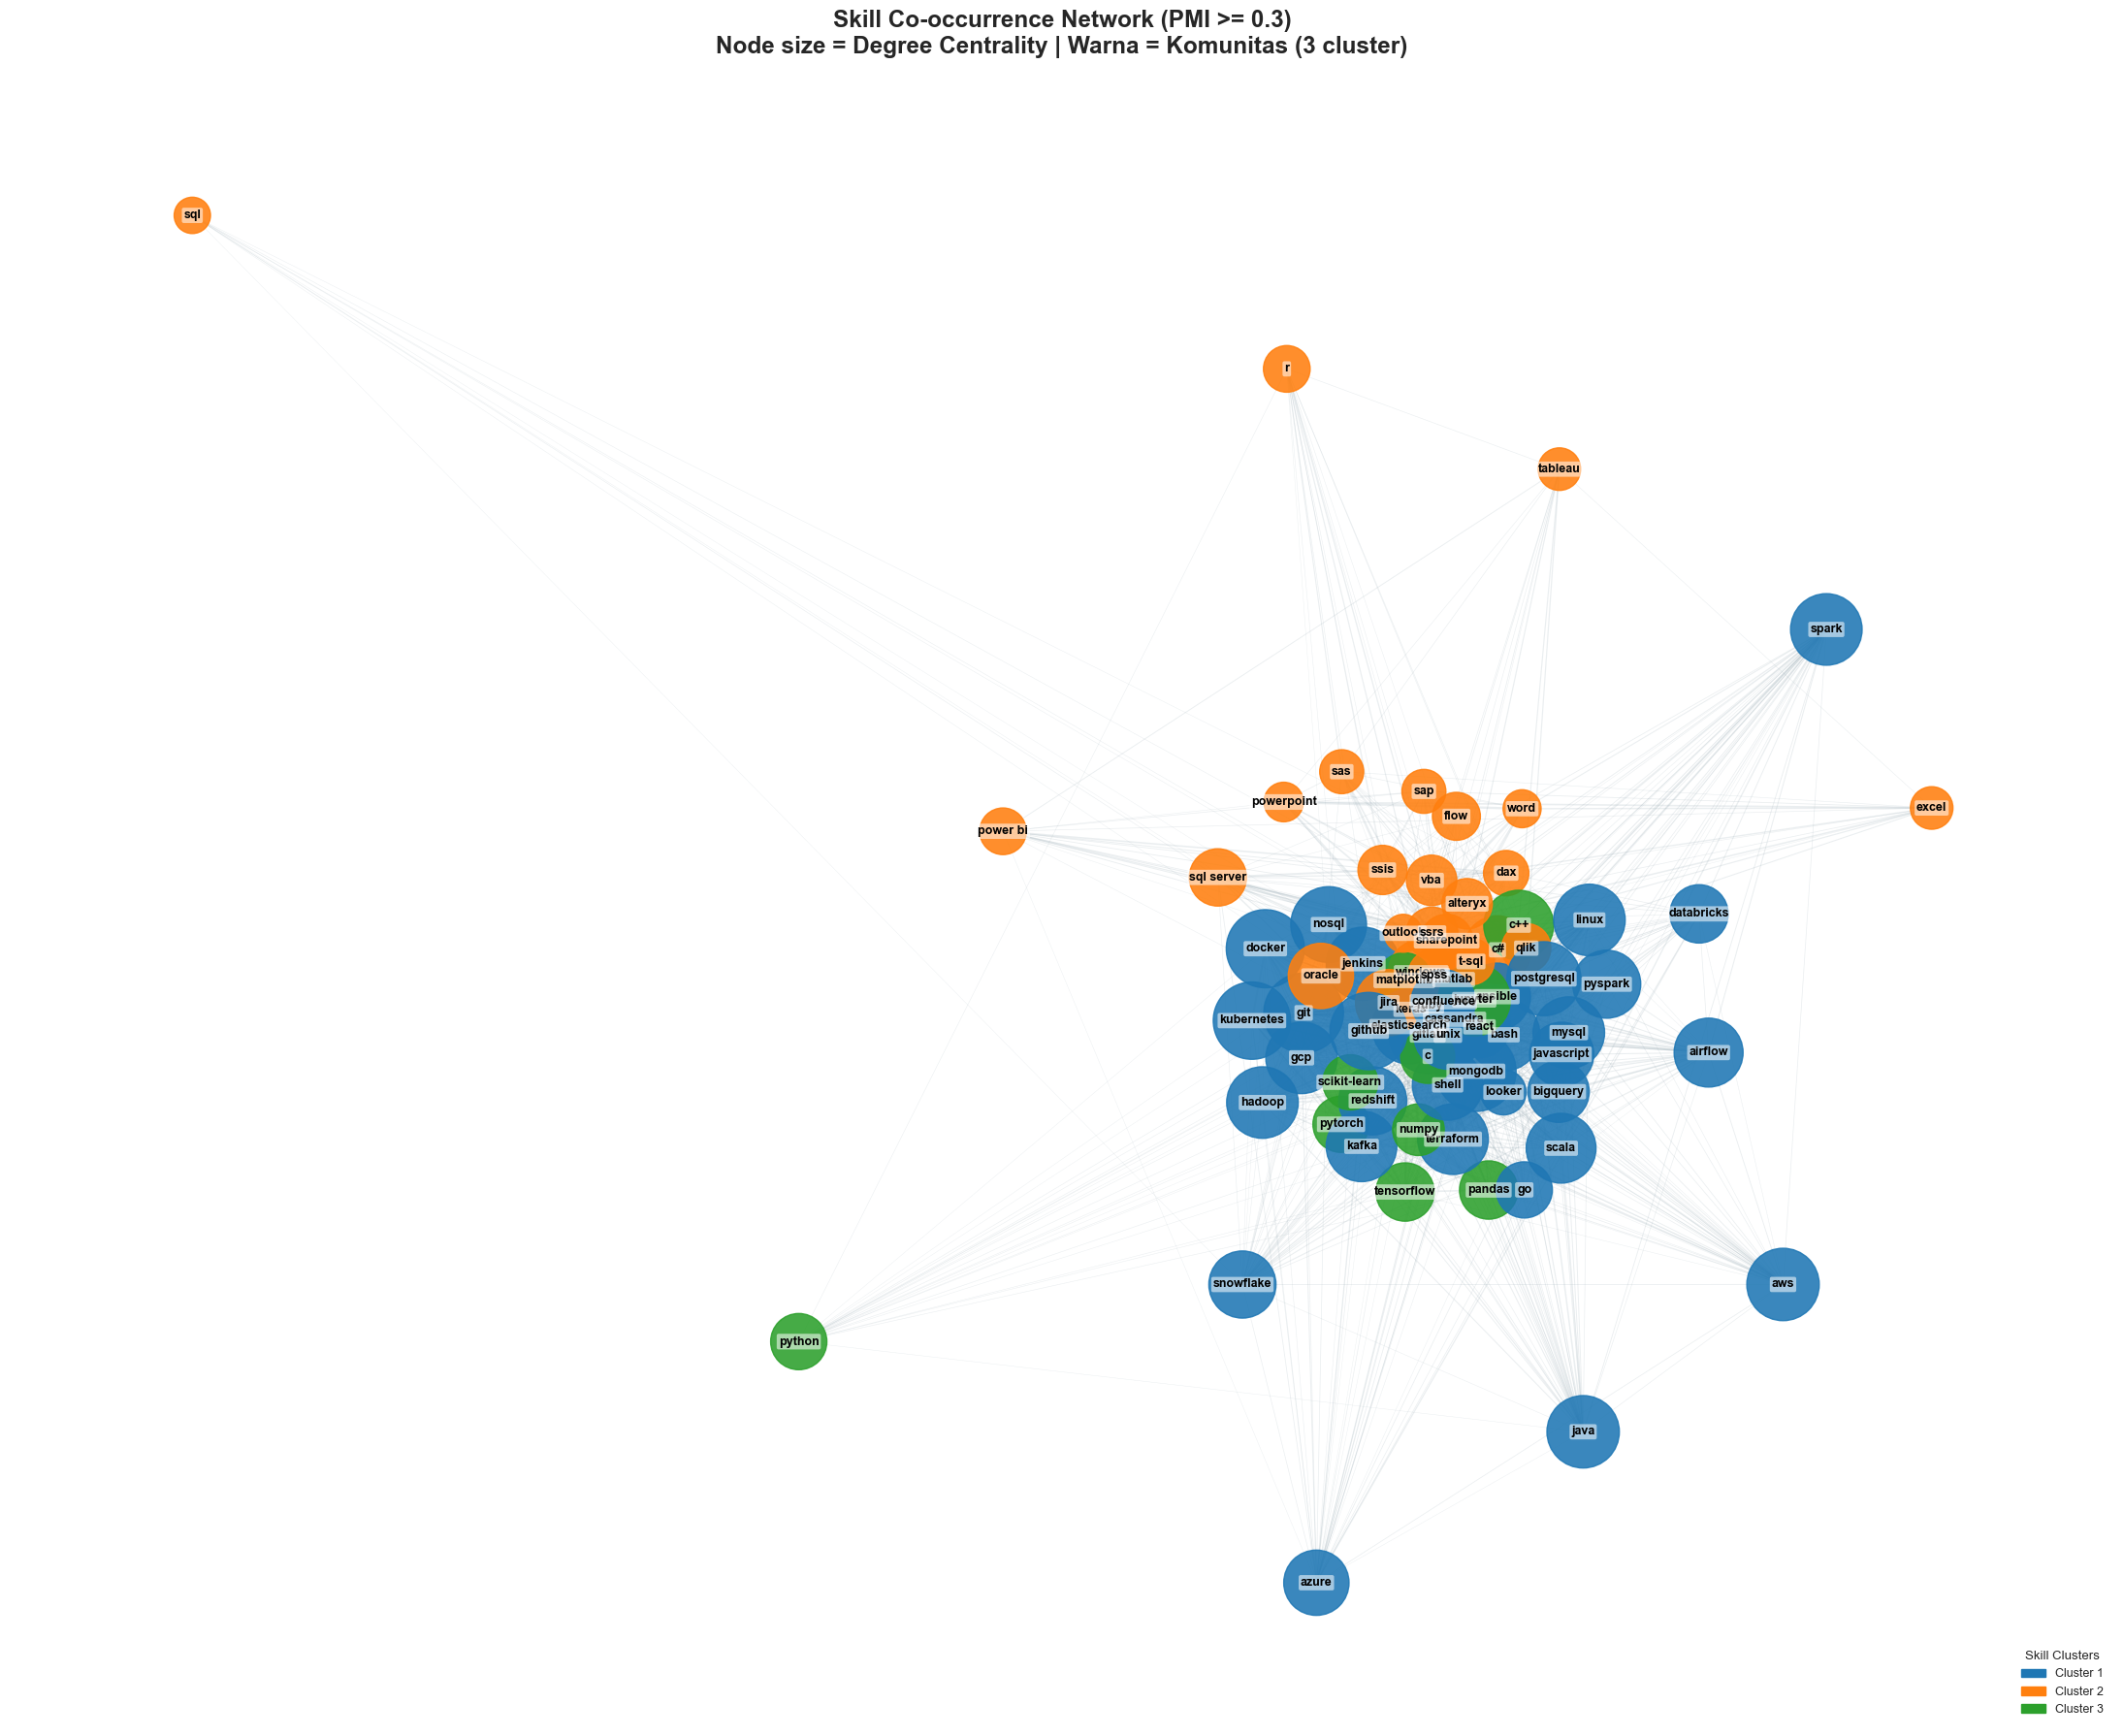

In [ ]:
#---------------------------------------------------
# 9.5 Network Visualization
#---------------------------------------------------
if G.number_of_nodes() > 0:
    fig, ax = plt.subplots(figsize=(22, 18))

    # Kamada-Kawai menyebarkan node lebih merata dibanding spring_layout
    try:
        pos = nx.kamada_kawai_layout(G, weight='weight')
    except Exception:
        pos = nx.spring_layout(G, seed=RANDOM_STATE, k=2.5 / math.sqrt(max(G.number_of_nodes(), 1)))

    node_colors = [cmap_net(partition.get(node, 0) % 10) for node in G.nodes()]
    node_sizes  = [degree_cent.get(node, 0.01) * 5000 + 120 for node in G.nodes()]

    edge_pmis   = [G[u][v].get('pmi', 0) for u, v in G.edges()]
    max_pmi     = max(edge_pmis) if edge_pmis else 1
    edge_widths = [p / max_pmi * 2.0 + 0.15 for p in edge_pmis]

    nx.draw_networkx_edges(G, pos, ax=ax,
                           width=edge_widths, alpha=0.18, edge_color='#90A4AE')
    nx.draw_networkx_nodes(G, pos, ax=ax,
                           node_color=node_colors, node_size=node_sizes, alpha=0.88)

    # Label SEMUA node — font kecil dengan bbox agar terbaca di atas node
    all_labels = {n: n for n in G.nodes()}
    nx.draw_networkx_labels(
        G, pos,
        labels=all_labels,
        ax=ax,
        font_size=9,
        font_weight='bold',
        bbox=dict(boxstyle='round,pad=0.15', fc='white', alpha=0.55, ec='none')
    )

    ax.set_title(
        f'Skill Co-occurrence Network (PMI >= {PMI_THRESHOLD})\n'
        f'Node size = Degree Centrality | Warna = Komunitas ({n_communities} cluster)',
        fontsize=17.5, fontweight='bold', pad=14
    )
    ax.axis('off')

    legend_handles = [
        mpatches.Patch(color=cmap_net(i % 10), label=f'Cluster {i+1}')
        for i in range(min(n_communities, 10))
    ]
    ax.legend(handles=legend_handles, loc='lower right',
              fontsize=9, title='Skill Clusters', title_fontsize=9.5)

    plt.tight_layout()
    plt.savefig('plot_skill_network.png', dpi=130, bbox_inches='tight')
    plt.show()

else:
    print("[SKIP] Network kosong, visualisasi dilewati.")

Visualisasi network memperlihatkan struktur ekosistem skill secara keseluruhan. Node yang lebih besar adalah skill yang lebih banyak terhubung ke skill lain. Warna yang sama menandai skill yang berada dalam komunitas yang sama, artinya mereka sering muncul bersama dan membentuk "paket skill" alami.

Saving -> ../outputs/figures\plot_bridge_skills.png


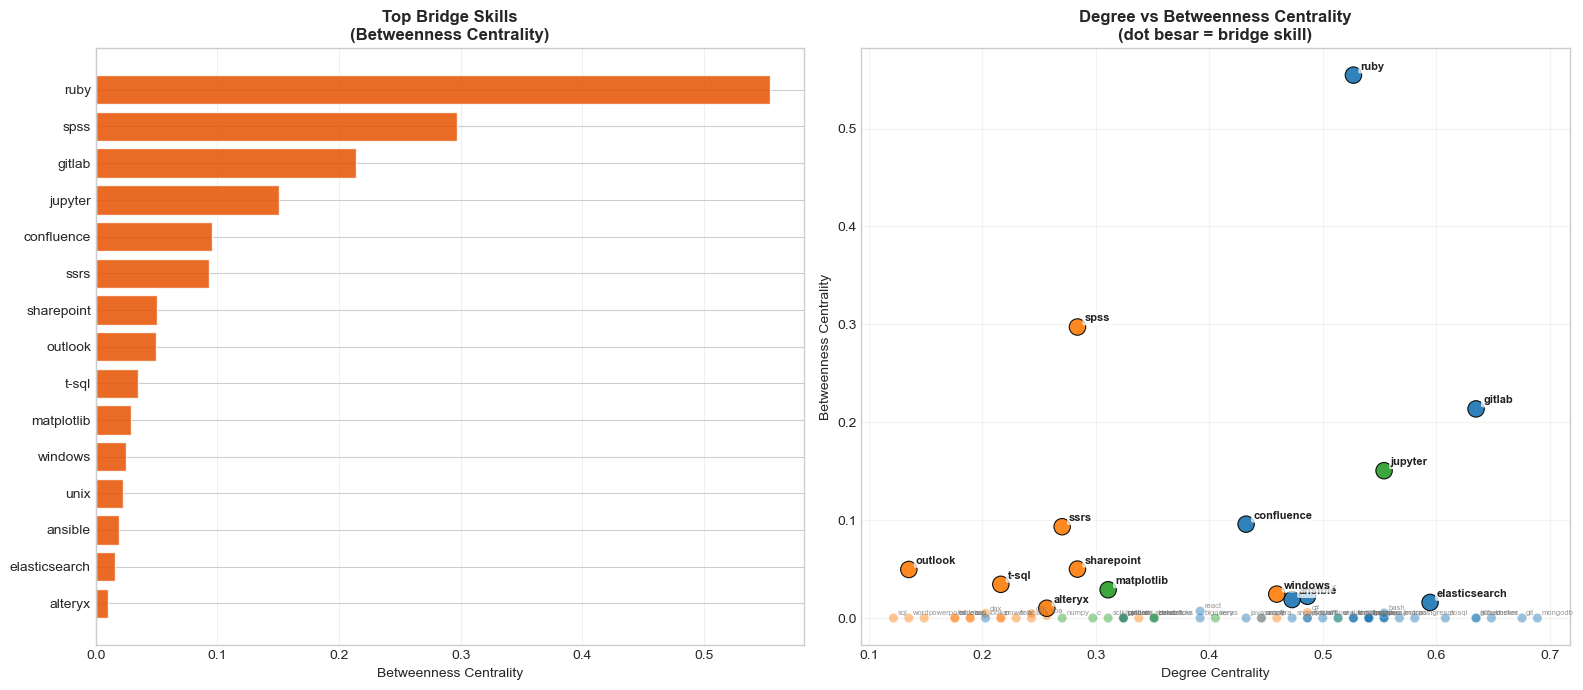

Top 15 Bridge Skills:


,skill,degree_centrality,betweenness_centrality,community
23,ruby,0.5270,0.5546,0
53,spss,0.2838,0.2973,1
3,gitlab,0.6351,0.2136,0
14,jupyter,0.5541,0.1505,2
37,confluence,0.4324,0.0959,0
56,ssrs,0.2703,0.0933,1
54,sharepoint,0.2838,0.0500,1
72,outlook,0.1351,0.0496,1
62,t-sql,0.2162,0.0344,1
51,matplotlib,0.3108,0.0289,2



=== TOP 10 SKILL PER KOMUNITAS (Degree Centrality) ===

Cluster 1 (38 skill total):


,Skill,Degree,Betweenness
1,mongodb,0.6892,0.0000
2,git,0.6757,0.0000
3,docker,0.6486,0.0000
4,gitlab,0.6351,0.2136
5,github,0.6351,0.0000
6,kubernetes,0.6351,0.0000
7,nosql,0.6081,0.0000
8,elasticsearch,0.5946,0.0159
9,postgresql,0.5811,0.0000
10,jenkins,0.5676,0.0000



Cluster 2 (26 skill total):


,Skill,Degree,Betweenness
1,c#,0.4865,0.0056
2,jira,0.4595,0.0000
3,windows,0.4595,0.0244
4,oracle,0.4459,0.0000
5,sql server,0.3378,0.0000
6,matlab,0.3243,0.0004
7,spss,0.2838,0.2973
8,sharepoint,0.2838,0.0500
9,ssrs,0.2703,0.0933
10,alteryx,0.2568,0.0100



Cluster 3 (11 skill total):


,Skill,Degree,Betweenness
1,jupyter,0.5541,0.1505
2,c++,0.5135,0.0000
3,keras,0.4054,0.0000
4,pandas,0.3514,0.0000
5,tensorflow,0.3514,0.0000
6,pytorch,0.3243,0.0000
7,python,0.3243,0.0000
8,scikit-learn,0.3108,0.0000
9,matplotlib,0.3108,0.0289
10,c,0.2973,0.0000


In [ ]:
#---------------------------------------------------
# 9.6 Bridge Skills Analysis
#---------------------------------------------------
if not centrality_df.empty:
    bt_threshold = centrality_df['betweenness_centrality'].quantile(0.80)
    bridge_df    = (centrality_df[centrality_df['betweenness_centrality'] >= bt_threshold]
                    .sort_values('betweenness_centrality', ascending=False)
                    .head(15))

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    # --- Plot Kiri: Bar chart bridge skills ---
    ax1 = axes[0]
    ax1.barh(bridge_df['skill'][::-1], bridge_df['betweenness_centrality'][::-1],
             color=COLOR_ACCENT, alpha=0.85, edgecolor='white')
    ax1.set_title('Top Bridge Skills\n(Betweenness Centrality)', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Betweenness Centrality', fontsize=10)
    ax1.grid(True, axis='x', alpha=0.3)

    # --- Plot Kanan: Scatter semua node, label bertingkat ---
    ax2 = axes[1]

    bridge_names = set(bridge_df['skill'].tolist())

    non_bridge = centrality_df[~centrality_df['skill'].isin(bridge_names)]
    is_bridge  = centrality_df[centrality_df['skill'].isin(bridge_names)]

    ax2.scatter(
        non_bridge['degree_centrality'],
        non_bridge['betweenness_centrality'],
        c=[cmap_net(int(r) % 10) for r in non_bridge['community']],
        s=45, alpha=0.45, edgecolors='white', linewidth=0.4, zorder=2
    )
    ax2.scatter(
        is_bridge['degree_centrality'],
        is_bridge['betweenness_centrality'],
        c=[cmap_net(int(r) % 10) for r in is_bridge['community']],
        s=140, alpha=0.92, edgecolors='black', linewidth=0.8, zorder=3
    )

    for _, row in non_bridge.iterrows():
        ax2.annotate(
            row['skill'],
            (row['degree_centrality'], row['betweenness_centrality']),
            fontsize=5.5, color='#757575', alpha=0.75,
            xytext=(3, 2), textcoords='offset points'
        )
    for _, row in is_bridge.iterrows():
        ax2.annotate(
            row['skill'],
            (row['degree_centrality'], row['betweenness_centrality']),
            fontsize=8, fontweight='bold', color='#212121',
            xytext=(5, 4), textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.18', fc='white', alpha=0.75, ec='none')
        )

    ax2.set_title('Degree vs Betweenness Centrality\n(dot besar = bridge skill)',
                  fontsize=12, fontweight='bold')
    ax2.set_xlabel('Degree Centrality', fontsize=10)
    ax2.set_ylabel('Betweenness Centrality', fontsize=10)
    ax2.grid(True, alpha=0.25)

    plt.tight_layout()
    plt.savefig('plot_bridge_skills.png', dpi=130, bbox_inches='tight')
    plt.show()

    print("Top 15 Bridge Skills:")
    display(bridge_df[
        ['skill', 'degree_centrality', 'betweenness_centrality', 'community']
    ].round(4))

    # Top 10 skill per komunitas berdasarkan degree centrality
    print("\n=== TOP 10 SKILL PER KOMUNITAS (Degree Centrality) ===")
    community_ids = sorted(centrality_df['community'].dropna().unique())
    for comm_id in community_ids:
        comm_df = (
            centrality_df[centrality_df['community'] == comm_id]
            .sort_values('degree_centrality', ascending=False)
            .head(10)
            .reset_index(drop=True)
        )
        comm_df.index += 1   # mulai dari 1
        print(f"\nCluster {int(comm_id) + 1} ({len(centrality_df[centrality_df['community'] == comm_id])} skill total):")
        display(
            comm_df[['skill', 'degree_centrality', 'betweenness_centrality']]
            .round(4)
            .rename(columns={
                'skill'                 : 'Skill',
                'degree_centrality'     : 'Degree',
                'betweenness_centrality': 'Betweenness'
            })
        )

else:
    print("[SKIP] centrality_df kosong.")

Bridge skills dengan betweenness centrality tinggi adalah skill yang paling langka dan bernilai tinggi dari perspektif career mobility. Mereka bukan selalu skill yang paling sering diminta (degree bisa menengah), tetapi posisi mereka di network memungkinkan seseorang untuk "berpindah" antara ekosistem skill yang biasanya terpisah.

Scatter plot di sebelah kanan memperlihatkan distribusi seluruh skill dalam ruang degree vs betweenness. Skill yang berada di pojok kanan atas adalah generalis sekaligus bridge, mereka paling strategis secara keseluruhan.

## **`[10]` Role-Based Skill Profiling**

TF-IDF adapted distinctiveness score mengukur seberapa "khas" suatu skill untuk role tertentu. Berbeda dari raw frequency, TF-IDF memberikan skor rendah untuk skill yang umum di semua role (seperti SQL dan Python) dan skor tinggi untuk skill yang dominan di satu role tetapi jarang di role lain untuk mengungkap signature skill yang sesungguhnya.

In [ ]:
# ==================================================
# 10. ROLE-BASED SKILL PROFILING
# ==================================================

#---------------------------------------------------
# 10.1 Filter Role Valid
#---------------------------------------------------
role_posting_counts = df['job_title_short'].value_counts()
valid_roles         = role_posting_counts[role_posting_counts >= MIN_ROLE_SIZE].index.tolist()

print(f"Role valid (>= {MIN_ROLE_SIZE} posting): {len(valid_roles)}")
for r in valid_roles:
    print(f"  {r:<40}: {role_posting_counts[r]:,} posting")

top_skills_matrix = (
    df_skills_long['skill']
    .value_counts()
    .head(TOP_N_SKILLS_MAT)
    .index.tolist()
)

#---------------------------------------------------
# 10.2 Skill-Role TF Matrix
#---------------------------------------------------
df_for_matrix = df_skills_long[
    (df_skills_long['job_title_short'].isin(valid_roles)) &
    (df_skills_long['skill'].isin(top_skills_matrix))
].copy()

skill_role_raw = (
    df_for_matrix
    .groupby(['skill', 'job_title_short'])
    .size()
    .reset_index(name='count')
)
role_totals = (
    df[df['job_title_short'].isin(valid_roles)]
    .groupby('job_title_short')
    .size()
    .reset_index(name='role_total')
)
skill_role_raw = skill_role_raw.merge(role_totals, on='job_title_short')
skill_role_raw['tf'] = skill_role_raw['count'] / skill_role_raw['role_total']

tf_matrix = (
    skill_role_raw
    .pivot(index='skill', columns='job_title_short', values='tf')
    .reindex(index=top_skills_matrix, columns=valid_roles)
    .fillna(0)
)

print(f"\nTF Matrix shape: {tf_matrix.shape}")

#---------------------------------------------------
# 10.3 TF-IDF Adapted Distinctiveness Score
#---------------------------------------------------
n_roles          = len(valid_roles)
skills_in_n_roles = (tf_matrix > 0).sum(axis=1)
idf              = np.log(n_roles / (skills_in_n_roles + 1))   # +1 Laplace smoothing
tfidf_matrix     = tf_matrix.multiply(idf, axis=0)

print("Signature skill per role (TF-IDF tertinggi):")
for role in valid_roles:
    if role in tfidf_matrix.columns:
        top_s = tfidf_matrix[role].idxmax()
        score = tfidf_matrix[role].max()
        print(f"  {role:<40}: {top_s} ({score:.5f})")

Role valid (>= 1000 posting): 10
  Data Analyst                            : 195,710 posting
  Data Engineer                           : 185,846 posting
  Data Scientist                          : 171,969 posting
  Business Analyst                        : 48,965 posting
  Software Engineer                       : 44,757 posting
  Senior Data Engineer                    : 44,470 posting
  Senior Data Scientist                   : 36,907 posting
  Senior Data Analyst                     : 29,176 posting
  Machine Learning Engineer               : 14,044 posting
  Cloud Engineer                          : 12,296 posting

TF Matrix shape: (40, 10)
Signature skill per role (TF-IDF tertinggi):
  Data Analyst                            : pytorch (-0.00024)
  Data Engineer                           : powerpoint (-0.00064)
  Data Scientist                          : redshift (-0.00158)
  Business Analyst                        : pytorch (-0.00013)
  Software Engineer                       : py

Saving -> ../outputs/figures\plot_skill_role_heatmap.png


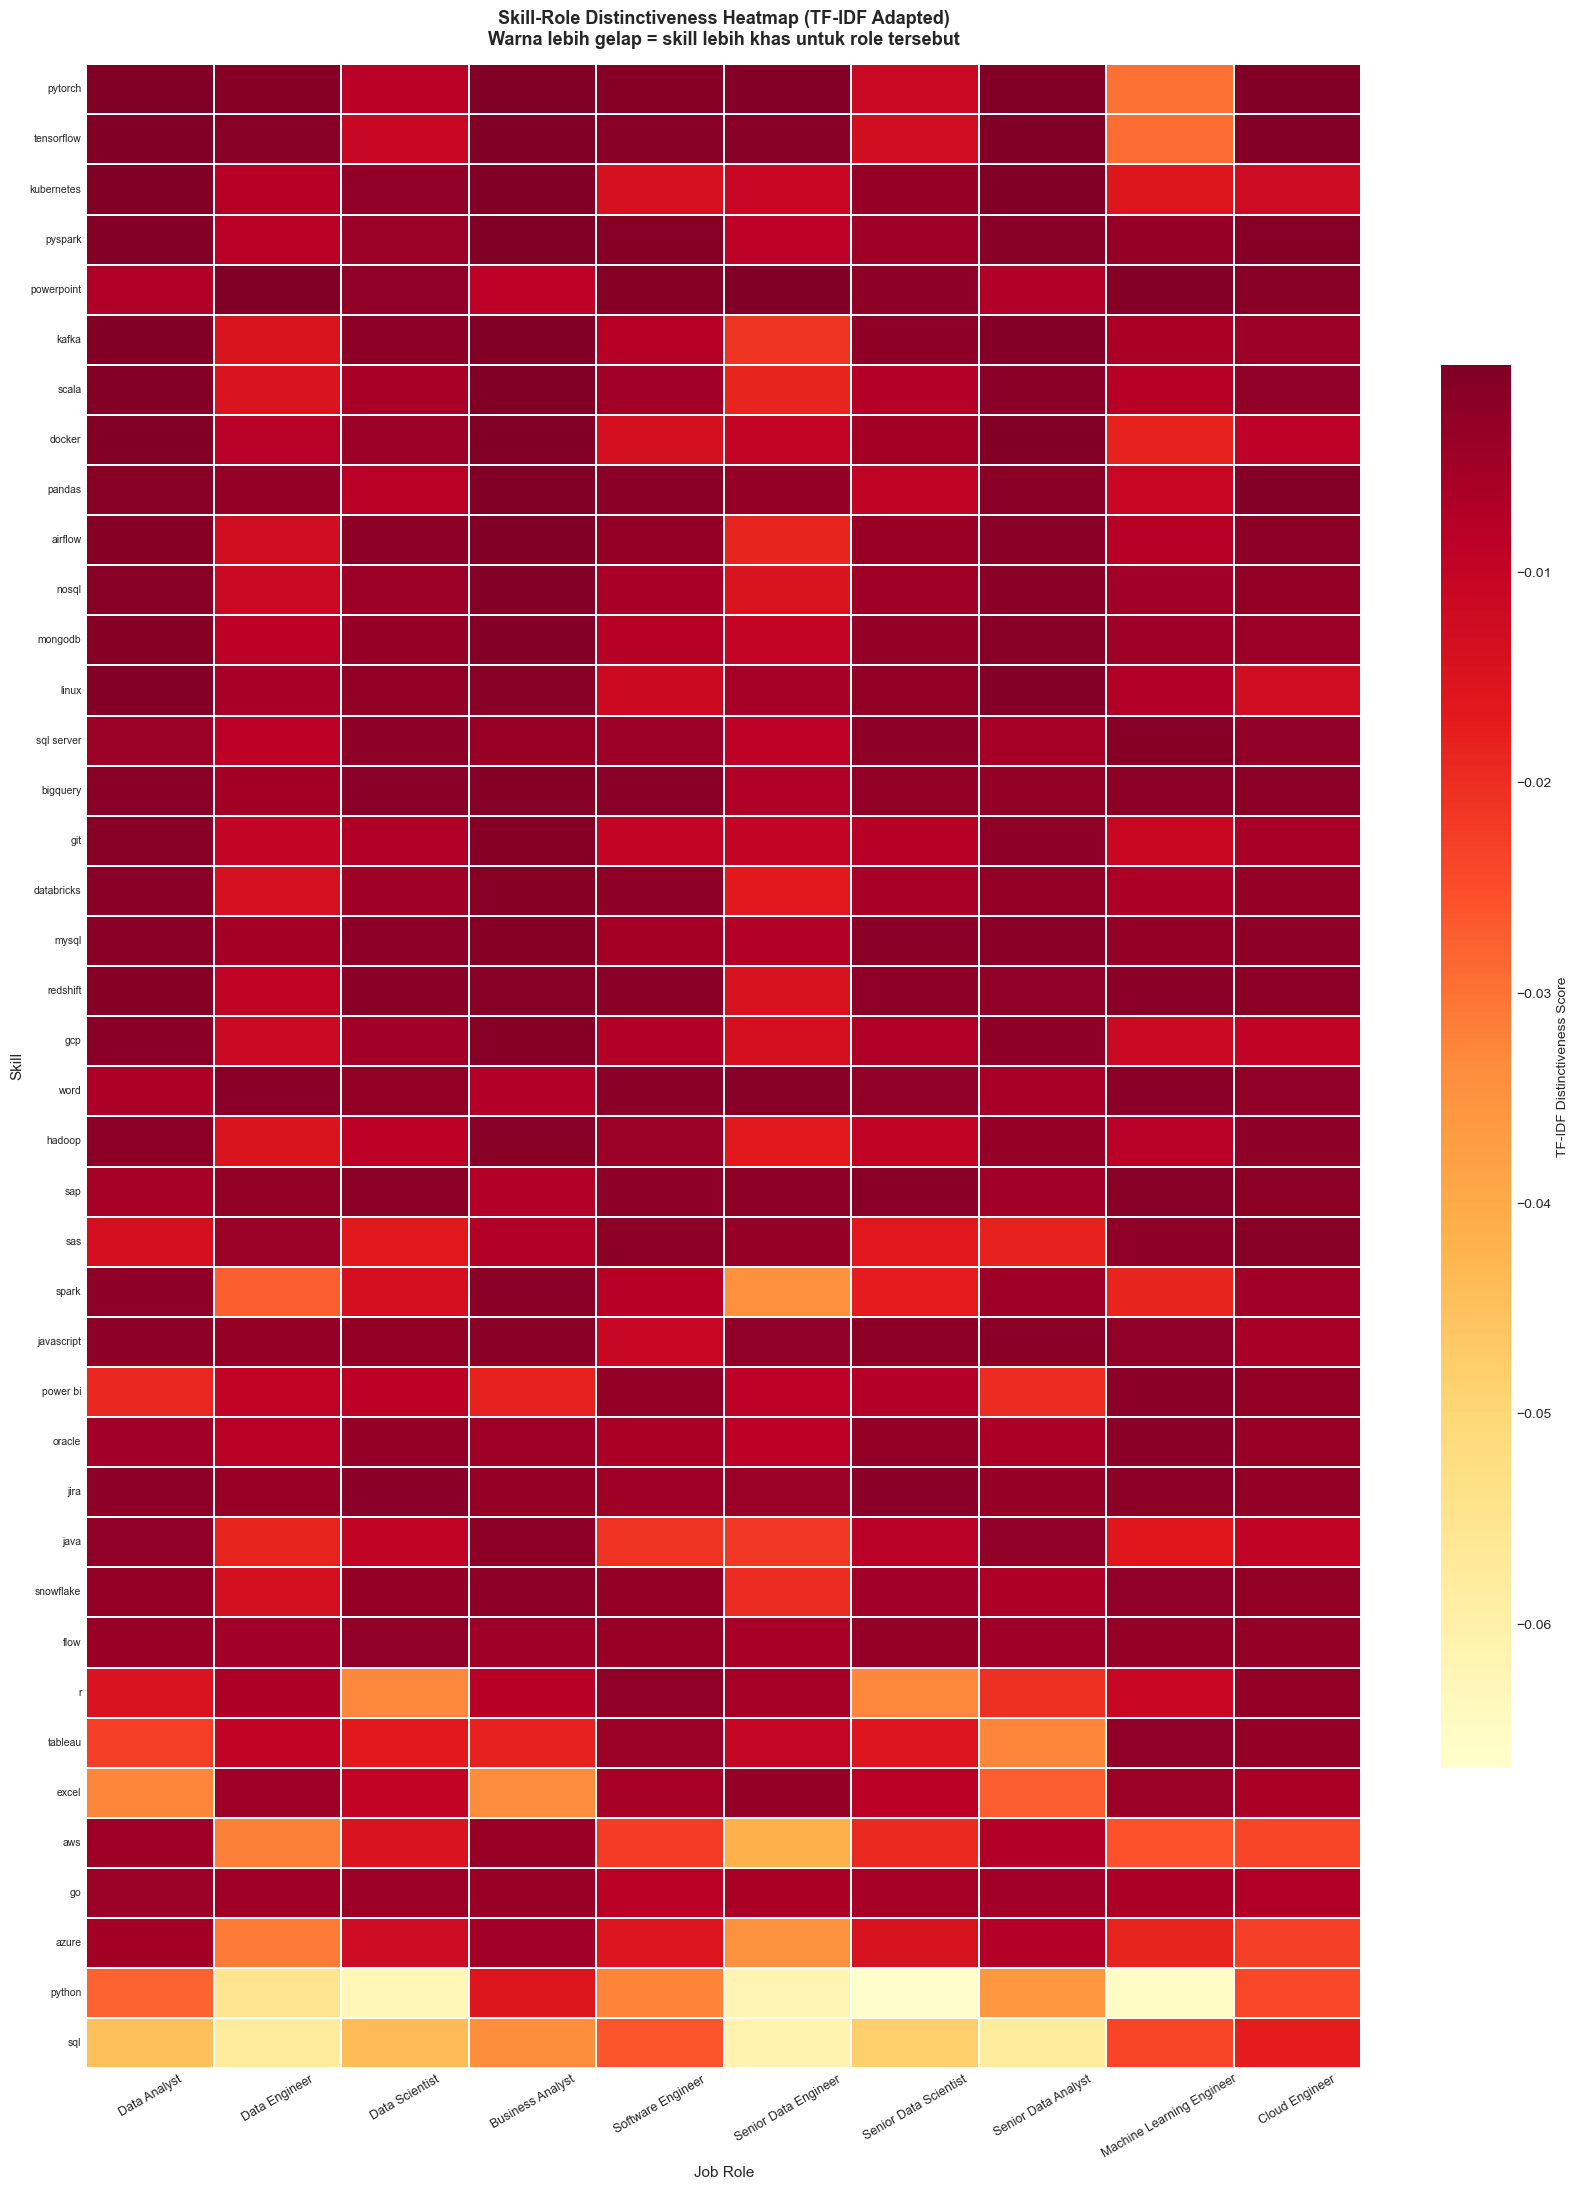

In [ ]:
#---------------------------------------------------
# 10.4 Skill-Role Heatmap (TF-IDF Distinctiveness)
#---------------------------------------------------
tfidf_sorted = tfidf_matrix.loc[tfidf_matrix.max(axis=1).sort_values(ascending=False).index]

n_r   = len(valid_roles)
n_s   = len(top_skills_matrix)
fig_h = min(22, n_s * 0.54 + 2)
fig_w = max(10, n_r * 1.7)

fig, ax = plt.subplots(figsize=(fig_w, fig_h))
sns.heatmap(
    tfidf_sorted,
    ax=ax,
    cmap='YlOrRd',
    linewidths=0.25,
    linecolor='white',
    annot=(n_r <= 8),
    fmt='.3f',
    annot_kws={'size': 7},
    cbar_kws={'label': 'TF-IDF Distinctiveness Score', 'shrink': 0.7}
)
ax.set_title(
    'Skill-Role Distinctiveness Heatmap (TF-IDF Adapted)\n'
    'Warna lebih gelap = skill lebih khas untuk role tersebut',
    fontsize=13, fontweight='bold', pad=14
)
ax.set_xlabel('Job Role', fontsize=11)
ax.set_ylabel('Skill', fontsize=11)
ax.tick_params(axis='x', rotation=30, labelsize=9)
ax.tick_params(axis='y', labelsize=7.5)
plt.tight_layout()
plt.savefig('plot_skill_role_heatmap.png', dpi=DPI, bbox_inches='tight')
plt.show()

Skill yang muncul gelap di semua kolom (warna merata) memiliki IDF rendah karena umum di semua role (bukan differentiator). Skill yang gelap hanya di satu atau dua kolom adalah signature skill yang paling informatif dan menjadi pertanyaan inti *"Jika kamu ingin menjadi X, skill apa yang benar-benar membedakanmu?"*

Saving -> ../outputs/figures\plot_role_overlap.png


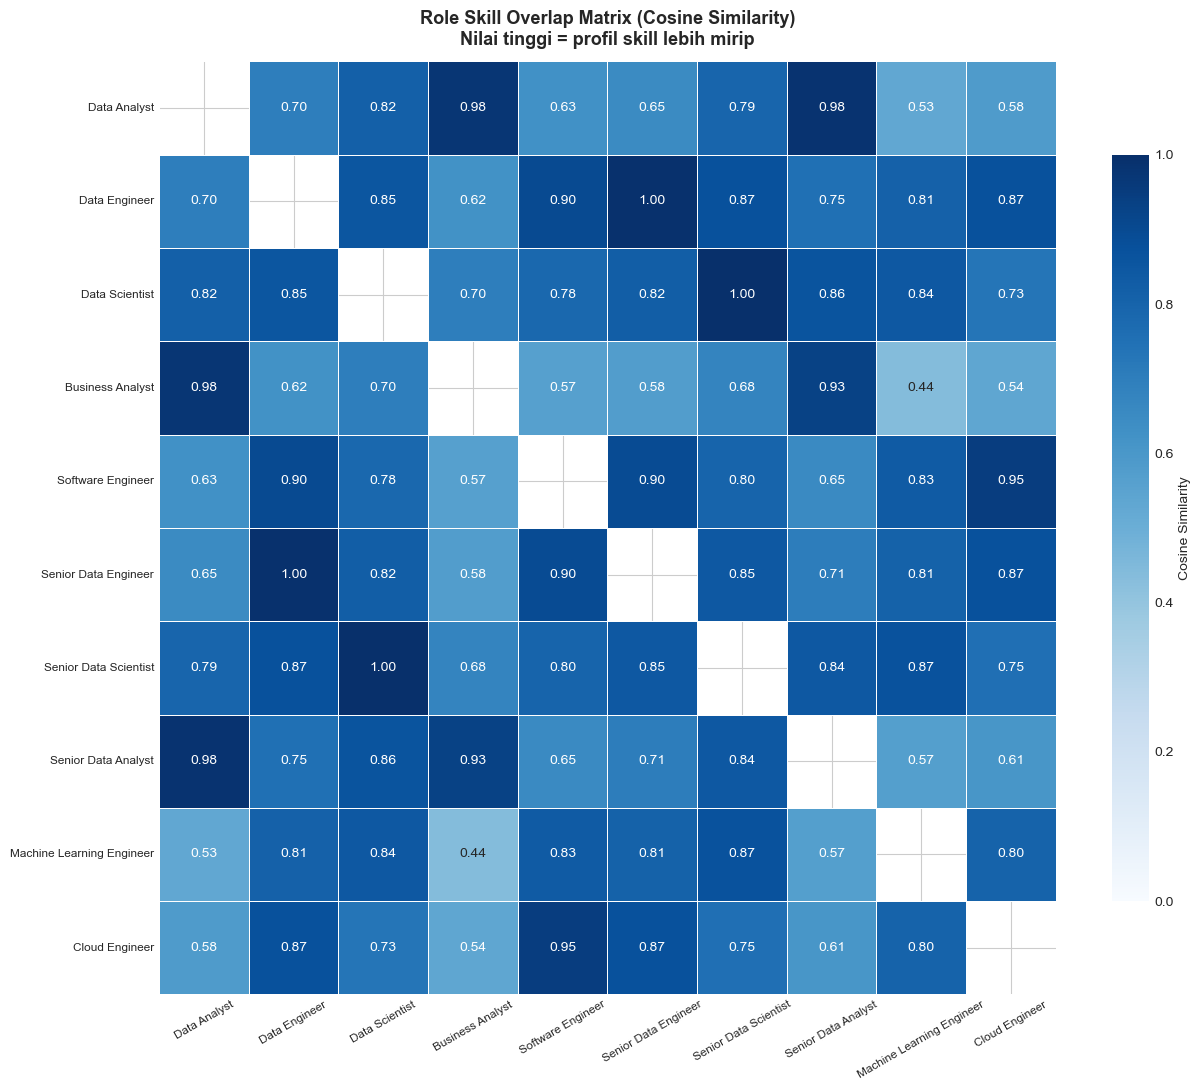

In [ ]:
#---------------------------------------------------
# 10.5 Role Skill Overlap Matrix (Cosine Similarity)
#---------------------------------------------------
from numpy.linalg import norm

def cosine_sim(v1, v2):
    d = norm(v1) * norm(v2)
    return float(np.dot(v1, v2) / d) if d > 0 else 0.0

overlap_matrix = pd.DataFrame(index=valid_roles, columns=valid_roles, dtype=float)
for r1 in valid_roles:
    for r2 in valid_roles:
        if r1 in tf_matrix.columns and r2 in tf_matrix.columns:
            overlap_matrix.loc[r1, r2] = cosine_sim(
                tf_matrix[r1].values, tf_matrix[r2].values
            )
overlap_matrix = overlap_matrix.astype(float)

mask_diag = np.eye(len(valid_roles), dtype=bool)
fig, ax = plt.subplots(figsize=(max(8, n_r * 1.3), max(7, n_r * 1.1)))
sns.heatmap(
    overlap_matrix, ax=ax, cmap='Blues', annot=True, fmt='.2f',
    linewidths=0.5, linecolor='white', mask=mask_diag,
    cbar_kws={'label': 'Cosine Similarity', 'shrink': 0.8}, vmin=0, vmax=1
)
ax.set_title('Role Skill Overlap Matrix (Cosine Similarity)\nNilai tinggi = profil skill lebih mirip',
             fontsize=13, fontweight='bold', pad=12)
ax.tick_params(axis='x', rotation=30, labelsize=8.5)
ax.tick_params(axis='y', rotation=0, labelsize=8.5)
plt.tight_layout()
plt.savefig('plot_role_overlap.png', dpi=DPI, bbox_inches='tight')
plt.show()

Matrix overlap menggunakan cosine similarity untuk mengukur seberapa mirip profil skill antar dua role. Nilai mendekati 1.0 berarti dua role berbagi proporsi skill yang sangat serupa, sementara nilai mendekati 0.0 menandai dua ekosistem skill yang sangat berbeda.

Ini adalah alat analitis untuk career transition. Pasangan role dengan cosine similarity tinggi secara teori lebih mudah dipivot karena fondasi skill yang sudah dimiliki sudah cukup tumpang tindih. Role dengan similarity rendah memerlukan effort re-learning yang lebih besar.

## **`[11]` Synthesis: Strategic Insights**

In [ ]:
# ==================================================
# 11. SYNTHESIS: STRATEGIC INSIGHTS
# ==================================================

#---------------------------------------------------
# 11.1 Auto-generated Key Findings Summary
#---------------------------------------------------
SEP = "=" * 62

print(SEP)
print("RINGKASAN TEMUAN UTAMA — TALENT MARKET SKILL DRIFT STUDY 2023")
print(SEP)

# Finding 1
top5 = df_skills_long['skill'].value_counts().head(5)
print("\n[1] TOP 5 SKILL PALING BANYAK DIMINTA:")
for i, (skill, cnt) in enumerate(top5.items(), 1):
    pct = cnt / len(df) * 100
    print(f"    {i}. {skill:<25} — {cnt:,} penyebutan ({pct:.1f}% posting)")

# Finding 2: Emerging skills
if not df_growth.empty:
    rising = df_growth[df_growth['significant'] & (df_growth['growth_rate_pct'] > 0)].head(5)
    print("\n[2] TOP 5 EMERGING SKILLS (signifikan, H1 → H2 2023):")
    for _, row in rising.iterrows():
        print(f"    {row['skill']:<25} growth: +{row['growth_rate_pct']:.1f}% (p={row['p_value']:.4f})")

    # Finding 3: Declining skills
    declining = df_growth[df_growth['significant'] & (df_growth['growth_rate_pct'] < 0)].tail(5).iloc[::-1]
    print("\n[3] TOP 5 DECLINING SKILLS (signifikan, H1 → H2 2023):")
    for _, row in declining.iterrows():
        print(f"    {row['skill']:<25} growth: {row['growth_rate_pct']:.1f}% (p={row['p_value']:.4f})")

# Finding 4: Network insights
if not centrality_df.empty:
    top_degree  = centrality_df.iloc[0]['skill']
    top_between = centrality_df.sort_values('betweenness_centrality', ascending=False).iloc[0]['skill']
    print(f"\n[4] NETWORK INSIGHTS:")
    print(f"    Skill paling terhubung (degree centrality)    : {top_degree}")
    print(f"    Skill jembatan utama (betweenness centrality) : {top_between}")
    print(f"    Jumlah cluster ekosistem yang terdeteksi      : {n_communities}")

# Finding 5: Role profiling
if not tfidf_matrix.empty:
    print("\n[5] SIGNATURE SKILL PER ROLE (TF-IDF distinctiveness tertinggi):")
    for role in valid_roles:
        if role in tfidf_matrix.columns:
            top_s = tfidf_matrix[role].idxmax()
            score = tfidf_matrix[role].max()
            print(f"    {role:<40}: {top_s} (score: {score:.5f})")

# Finding 6: Role similarity extremes
if not overlap_matrix.empty:
    ov = overlap_matrix.copy()
    np.fill_diagonal(ov.values, np.nan)
    max_sim = ov.stack().idxmax()
    min_sim = ov.stack().idxmin()
    print(f"\n[6] ROLE OVERLAP (COSINE SIMILARITY):")
    print(f"    Pasangan role paling MIRIP   : {max_sim[0]} ↔ {max_sim[1]} ({ov.loc[max_sim[0], max_sim[1]]:.2f})")
    print(f"    Pasangan role paling BERBEDA : {min_sim[0]} ↔ {min_sim[1]} ({ov.loc[min_sim[0], min_sim[1]]:.2f})")

print("\n" + SEP)

RINGKASAN TEMUAN UTAMA — TALENT MARKET SKILL DRIFT STUDY 2023

[1] TOP 5 SKILL PALING BANYAK DIMINTA:
    1. sql                       — 384,084 penyebutan (49.0% posting)
    2. python                    — 380,158 penyebutan (48.5% posting)
    3. aws                       — 145,089 penyebutan (18.5% posting)
    4. azure                     — 132,271 penyebutan (16.9% posting)
    5. r                         — 130,650 penyebutan (16.7% posting)

[2] TOP 5 EMERGING SKILLS (signifikan, H1 → H2 2023):
    hugging face              growth: +78.2% (p=0.0000)
    ubuntu                    growth: +43.9% (p=0.0000)
    unity                     growth: +21.1% (p=0.0001)
    microsoft teams           growth: +20.5% (p=0.0125)
    openstack                 growth: +18.8% (p=0.0177)

[3] TOP 5 DECLINING SKILLS (signifikan, H1 → H2 2023):
    datarobot                 growth: -44.5% (p=0.0000)
    watson                    growth: -34.0% (p=0.0000)
    vue                       growth: -29.4% 

In [ ]:
import nbformat

nb = nbformat.read(
    "../notebooks/talent_market_skill_drift_study.ipynb",
    as_version=4
)

if "widgets" in nb.metadata:
    del nb.metadata["widgets"]

nbformat.write(
    nb,
    "../notebooks/talent_market_skill_drift_study.ipynb"
)

print("widgets metadata removed")

widgets metadata removed


## **`[12]` Kesimpulan**

Dari 785.741 job posting yang dianalisis, SQL (49,0%) dan Python (48,5%) muncul sebagai dua skill paling dominan dan hadir di hampir separuh seluruh lowongan. Temuan ini menunjukkan bahwa keduanya telah menjadi prasyarat dasar pasar data analytics, bukan lagi pembeda utama antar kandidat. Di bawahnya, AWS, Azure, dan R membentuk lapisan kompetensi kedua yang mengindikasikan semakin pentingnya penguasaan cloud platform dalam ekosistem data modern.

Analisis temporal menunjukkan adanya pergeseran permintaan yang cukup jelas sepanjang 2023. Hugging Face mencatat pertumbuhan tertinggi, diikuti Ubuntu, Unity, dan Microsoft Teams, yang mencerminkan meningkatnya adopsi AI, machine learning, serta perluasan peran data ke berbagai domain bisnis. Sebaliknya, DataRobot, Watson, Theano, dan R Shiny mengalami penurunan permintaan yang konsisten, mengindikasikan pergeseran pasar dari platform dan teknologi yang lebih lama menuju alternatif yang lebih modern dan fleksibel.

Analisis network mengungkap bahwa ekosistem skill data analytics tidak terbentuk sebagai satu kelompok yang homogen, melainkan terpecah ke dalam tiga komunitas utama. MongoDB muncul sebagai skill dengan konektivitas tertinggi, sedangkan GitLab, Jupyter, dan SPSS berperan sebagai bridge skill yang menghubungkan lebih dari satu komunitas. Posisi ini menunjukkan bahwa nilai suatu skill tidak hanya ditentukan oleh tingkat popularitasnya, tetapi juga oleh kemampuannya menjembatani berbagai domain teknologi.

Pada tingkat role, hasil profiling menunjukkan bahwa perbedaan antar posisi lebih banyak ditentukan oleh tooling dan kompetensi spesifik daripada skill dasar seperti SQL dan Python. Analisis kemiripan antar-role juga memperlihatkan bahwa fondasi skill di pasar data analytics relatif konvergen. Bahkan role yang tampak berbeda sekalipun masih memiliki tumpang tindih kompetensi yang cukup besar, sehingga transisi karier lintas role cenderung lebih realistis.

## **`[13]` Catatan & Temuan Utama**

**`a)` Catatan:**
1. Ruby mencatat betweenness centrality tertinggi (~0.55), tetapi kemungkinan besar dipengaruhi oleh posting hybrid yang menggabungkan data engineering dan backend web development. Karena itu, posisinya sebagai bridge skill perlu dipahami.

2. Dua skill yang
   jarang muncul secara individual tetapi sering muncul bersama di sejumlah kecil posting
   spesialis akan mendapatkan PMI yang sangat tinggi, bukan karena hubungannya kuat di
   pasar luas, tetapi karena denominatornya kecil. Edge dengan PMI tinggi tapi co-occurrence
   count rendah di network sebaiknya dibaca sebagai "relasi niche," bukan relasi umum.

**`b)` Temuan Utama:**
1. GitLab dan Jupyter muncul sebagai bridge skill yang menghubungkan lebih dari satu cluster dengan volume demand yang memadai. Posisi ini menjadikannya aset yang bernilai untuk mobilitas karier lintas ekosistem teknologi.

2. Skill yang paling populer belum tentu menjadi pembeda utama antar-role. Hasil TF-IDF menunjukkan bahwa skill dengan distinctiveness tinggi lebih merepresentasikan kompetensi spesifik yang benar-benar dicari perusahaan.

3. Role overlap matrix menunjukkan bahwa transisi karier paling realistis umumnya terjadi antar-role karena memiliki fondasi kemiripan skill yang tinggi. Semakin rendah kemiripannya, semakin besar effort belajar yang dibutuhkan.

---

<p align="right">
<i>Ahmad Kenzy Farzaq • 2026</i>
</p>